- Missing values uitleggen
- Missing values verklaren
- Placeholder values uitzoeken
- Placeholder values verklaren
- Missing values invullen?
- Echt per feature uitleggen en verklaren niet zomaar iets doen zonder onderbouwing.
- Feature Time series analysis
- Target variable price change (Time series)

# GitIgnore

Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

In [1]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

import numpy as np

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms, models

from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix

c:\Users\Ayoub\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("../Dataset/us-derived-shareprices-daily.csv", sep=";")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset. Although additional features were available in the dataset, they were excluded because they were not identified as relevant indicators during the stakeholder interview and literature review. Since explainability and domain relevance were prioritised over purely predictive performance, only stakeholder-supported variables were used for model development.


In [3]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")


df = pd.read_csv("../filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


In this describe even if it is in scientific notation. We can already cleary see in the min and max values huge discrepencies. We have 0 values, as well as huge values seen by the amount of zeros added to some max values.

This suggest that the dataset contains extreme outliers, as well as unusable values for training a model.

In [4]:
df.sample(5)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
72215,ACTG,2025-02-13,4.34,143110,4.225778e+08,NaN,NaN,0.70320,NaN,NaN,NaN,1.42207,NaN,NaN,0.00000
482099,AWRE,2023-04-12,1.67,61268,3.512511e+07,-20.90306,2.25379,0.89728,234.27714,-0.84952,0.38400,1.11448,-1.30077,0.86240,NaN
3741431,QSEP,2023-06-13,0.05,159164,1.927239e+07,NaN,NaN,-3.59591,NaN,NaN,NaN,-0.27809,NaN,NaN,NaN
266620,AMT,2024-10-14,210.21,1501964,1.035520e+11,NaN,NaN,9.92200,NaN,NaN,NaN,0.10079,NaN,NaN,NaN
2567273,KMT,2024-02-28,23.32,363406,1.968269e+09,16.37858,0.95970,1.49873,7.80066,7.81013,1.22306,0.66723,0.07558,2.94559,0.03215


Here is a random sample taken from the data which confirms our earlier idea. We can see alot of missing or unusable values as well as very fluctuating values. Since this is the baseline model we won't dive into fixing this.

In the baseline model we established there were recurring weird values so we're gonna take a deeper look into this. It would be interesting to get an idea of the values we have inside our dataset

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print(numeric_cols)

for col in numeric_cols:
    print("\n", col)
    print(
        df[col]
        .value_counts()
        .head(20)
    )

['Adj. Close', 'Volume', 'Market-Cap', 'Price to Earnings Ratio (ttm)', 'Price to Sales Ratio (ttm)', 'Price to Book Value', 'Price to Free Cash Flow (ttm)', 'EV/EBITDA', 'EV/Sales', 'Book to Market Value', 'Operating Income/EV', 'Altman Z Score', 'Dividend Yield']

 Adj. Close
Adj. Close
0.00     55304
0.01     18181
0.02     11107
0.03      8376
0.04      8108
0.05      6907
1.00      6559
0.10      5614
0.06      5591
10.00     5484
2.00      5304
5.00      5282
0.07      5081
3.00      4539
0.17      4177
2.50      4144
1.50      4025
0.20      3975
0.15      3968
4.00      3945
Name: count, dtype: int64

 Volume
Volume
0       195157
1         9345
100       7303
2         5367
3         3446
200       3343
5         2927
4         2683
10        2666
1000      2202
6         2037
500       1949
300       1874
20        1573
7         1566
50        1483
8         1448
400       1399
12        1181
11        1180
Name: count, dtype: int64

 Market-Cap
Market-Cap
0.000000e+00    56

Initially, the dataset appeared to contain complete observations. However, frequency analysis revealed repeated occurrences of the values 99999.99999 and -99999.99999 across multiple financial ratios. Also values of 0 which in itself is no problem, but they are heavily present in ratios were normally 0 values wouldn't be expected like P/E. These values were interpreted as placeholders rather than valid financial observations and were therefore converted to missing values before assessing dataset completeness. This ensured that completeness calculations reflected actual data availability rather than the presence of placeholder values.

The order in which we execute these operations is very important. If we would first delete all NaN and check for data completness per company and select those companies. And only after that remove placeholders. We would again be placed in a situation were we are uncertain about the state of our dataset.

In [6]:
placeholder_values = [
    99999.99999,
    -99999.99999
]

results = []

for col in numeric_cols:

    mask = df[col].isin(placeholder_values)

    results.append({
        "Feature": col,
        "Placeholder Count": mask.sum(),
        "Placeholder %": mask.mean() * 100,
        "Contribution %": df.loc[mask, col].abs().sum()/df[col].abs().sum()* 100
    })

placeholder_summary_df = pd.DataFrame(results)

placeholder_summary_df

,Feature,Placeholder Count,Placeholder %,Contribution %
0,Adj. Close,0,0.000000,0.000000
1,Volume,0,0.000000,0.000000
2,Market-Cap,0,0.000000,0.000000
3,Price to Earnings Ratio (ttm),1870,0.036831,27.656419
4,Price to Sales Ratio (ttm),3111,0.061274,49.576483
5,Price to Book Value,948,0.018672,31.750647
6,Price to Free Cash Flow (ttm),896,0.017647,24.377727
7,EV/EBITDA,343,0.006756,16.009938
8,EV/Sales,2412,0.047506,52.437234
9,Book to Market Value,220,0.004333,30.342019


In [7]:
clean_df = df.replace(
    placeholder_values,
    np.nan
)

stats_before = df[numeric_cols].describe().T
stats_after = clean_df[numeric_cols].describe().T

stats_comparison = pd.DataFrame({
    "Mean Before": stats_before["mean"],
    "Mean After": stats_after["mean"],
    "Std Before": stats_before["std"],
    "Std After": stats_after["std"],
    "Min Before": stats_before["min"],
    "Min After": stats_after["min"],
    "Max Before": stats_before["max"],
    "Max After": stats_after["max"]
})

stats_comparison

,Mean Before,Mean After,Std Before,Std After,Min Before,Min After,Max Before,Max After
Adj. Close,2.508054e+04,2.508054e+04,1.419652e+06,1.419652e+06,0.00000,0.00000,1.000000e+08,1.000000e+08
Volume,1.703947e+06,1.703947e+06,1.106200e+07,1.106200e+07,0.00000,0.00000,5.497020e+09,5.497020e+09
Market-Cap,4.219712e+12,4.219712e+12,4.197879e+14,4.197879e+14,0.00000,0.00000,5.698460e+16,5.698460e+16
Price to Earnings Ratio (ttm),-1.730331e+01,-1.067875e+01,2.812195e+03,1.656535e+03,-99999.99999,-99943.14578,1.000000e+05,8.890226e+04
Price to Sales Ratio (ttm),1.370486e+02,8.236509e+01,3.520416e+03,1.704842e+03,-99999.99999,-99894.01431,1.000000e+05,9.990815e+04
Price to Book Value,1.063825e+01,1.652057e+01,1.900016e+03,1.126365e+03,-99999.99999,-99617.75696,1.000000e+05,9.993253e+04
Price to Free Cash Flow (ttm),-2.022930e+01,-1.811944e+00,2.239674e+03,1.329887e+03,-99999.99999,-99709.71750,1.000000e+05,6.407077e+04
EV/EBITDA,1.040932e+00,-5.467772e-01,1.370573e+03,9.004355e+02,-99999.99999,-99820.23291,1.000000e+05,9.725865e+04
EV/Sales,7.648980e+01,4.378210e+01,3.095022e+03,1.431530e+03,-99999.99999,-99972.64000,1.000000e+05,9.997906e+04
Book to Market Value,1.096683e+01,6.687289e+00,8.267660e+02,3.602127e+02,-99999.99999,-50000.00000,1.000000e+05,5.000000e+04


Even after cleaning the dataset with the first supsected placeholders, there still seem to be other unexplainable large values and other suspected placeholders like -500.000/500.000, we will for now first look how much these outliers contribute to the dataset and if they are worth further cleaning.

In [8]:
extreme_threshold = 10000

results = []

for col in numeric_cols:

    mask = clean_df[col].abs() > extreme_threshold

    results.append({
        "Feature": col,
        "Extreme Count": mask.sum(),
        "Extreme %": mask.mean() * 100,
        "Contribution %":
            clean_df.loc[mask, col].abs().sum()
            /
            clean_df[col].abs().sum()
            * 100
    })

extreme_summary_df = pd.DataFrame(results)

extreme_summary_df

,Feature,Extreme Count,Extreme %,Contribution %
0,Adj. Close,13286,0.261678,99.757521
1,Volume,4241534,83.540431,99.976988
2,Market-Cap,4785368,94.251680,100.000000
3,Price to Earnings Ratio (ttm),8815,0.173619,46.897626
4,Price to Sales Ratio (ttm),5878,0.115772,61.037989
5,Price to Book Value,3641,0.071712,55.060859
6,Price to Free Cash Flow (ttm),4215,0.083018,38.884778
7,EV/EBITDA,2439,0.048038,35.106905
8,EV/Sales,3793,0.074706,58.573566
9,Book to Market Value,897,0.017667,34.113021


Even after cleaning placeholders we can still see a small percentage of extreme values still dominates the features. Making them unreliable. We can check a very modest treshold of 10.000. Based on our domain knowledge this treshold is very low for features like Volume and Market cap, but very high for the rest of the features. Which the data above confirms. A small percentage of the data contributes a out of proportion percentage of the features. 

In [9]:
for col in numeric_cols:

    print("\n", col)

    print(
        clean_df[col].quantile([
            0.001,
            0.005,
            0.01,
            0.05,
            0.95,
            0.99,
            0.995,
            0.999
        ])
    )


 Adj. Close
0.001         0.00000
0.005         0.00000
0.010         0.00000
0.050         0.64000
0.950       204.92000
0.990       707.54340
0.995      2560.51150
0.999    432561.16636
Name: Adj. Close, dtype: float64

 Volume
0.001    0.000000e+00
0.005    0.000000e+00
0.010    0.000000e+00
0.050    5.000000e+01
0.950    6.014906e+06
0.990    2.323762e+07
0.995    3.921792e+07
0.999    1.029897e+08
Name: Volume, dtype: float64

 Market-Cap
0.001    0.000000e+00
0.005    0.000000e+00
0.010    0.000000e+00
0.050    8.795970e+06
0.950    5.184526e+10
0.990    2.137250e+11
0.995    3.716949e+11
0.999    1.989423e+12
Name: Market-Cap, dtype: float64

 Price to Earnings Ratio (ttm)
0.001   -12807.329363
0.005    -1935.422130
0.010     -841.206510
0.050      -77.311560
0.950       77.184145
0.990      507.473594
0.995     1324.750972
0.999    11184.951954
Name: Price to Earnings Ratio (ttm), dtype: float64

 Price to Sales Ratio (ttm)
0.001      -42.649428
0.005        0.000000
0.010    

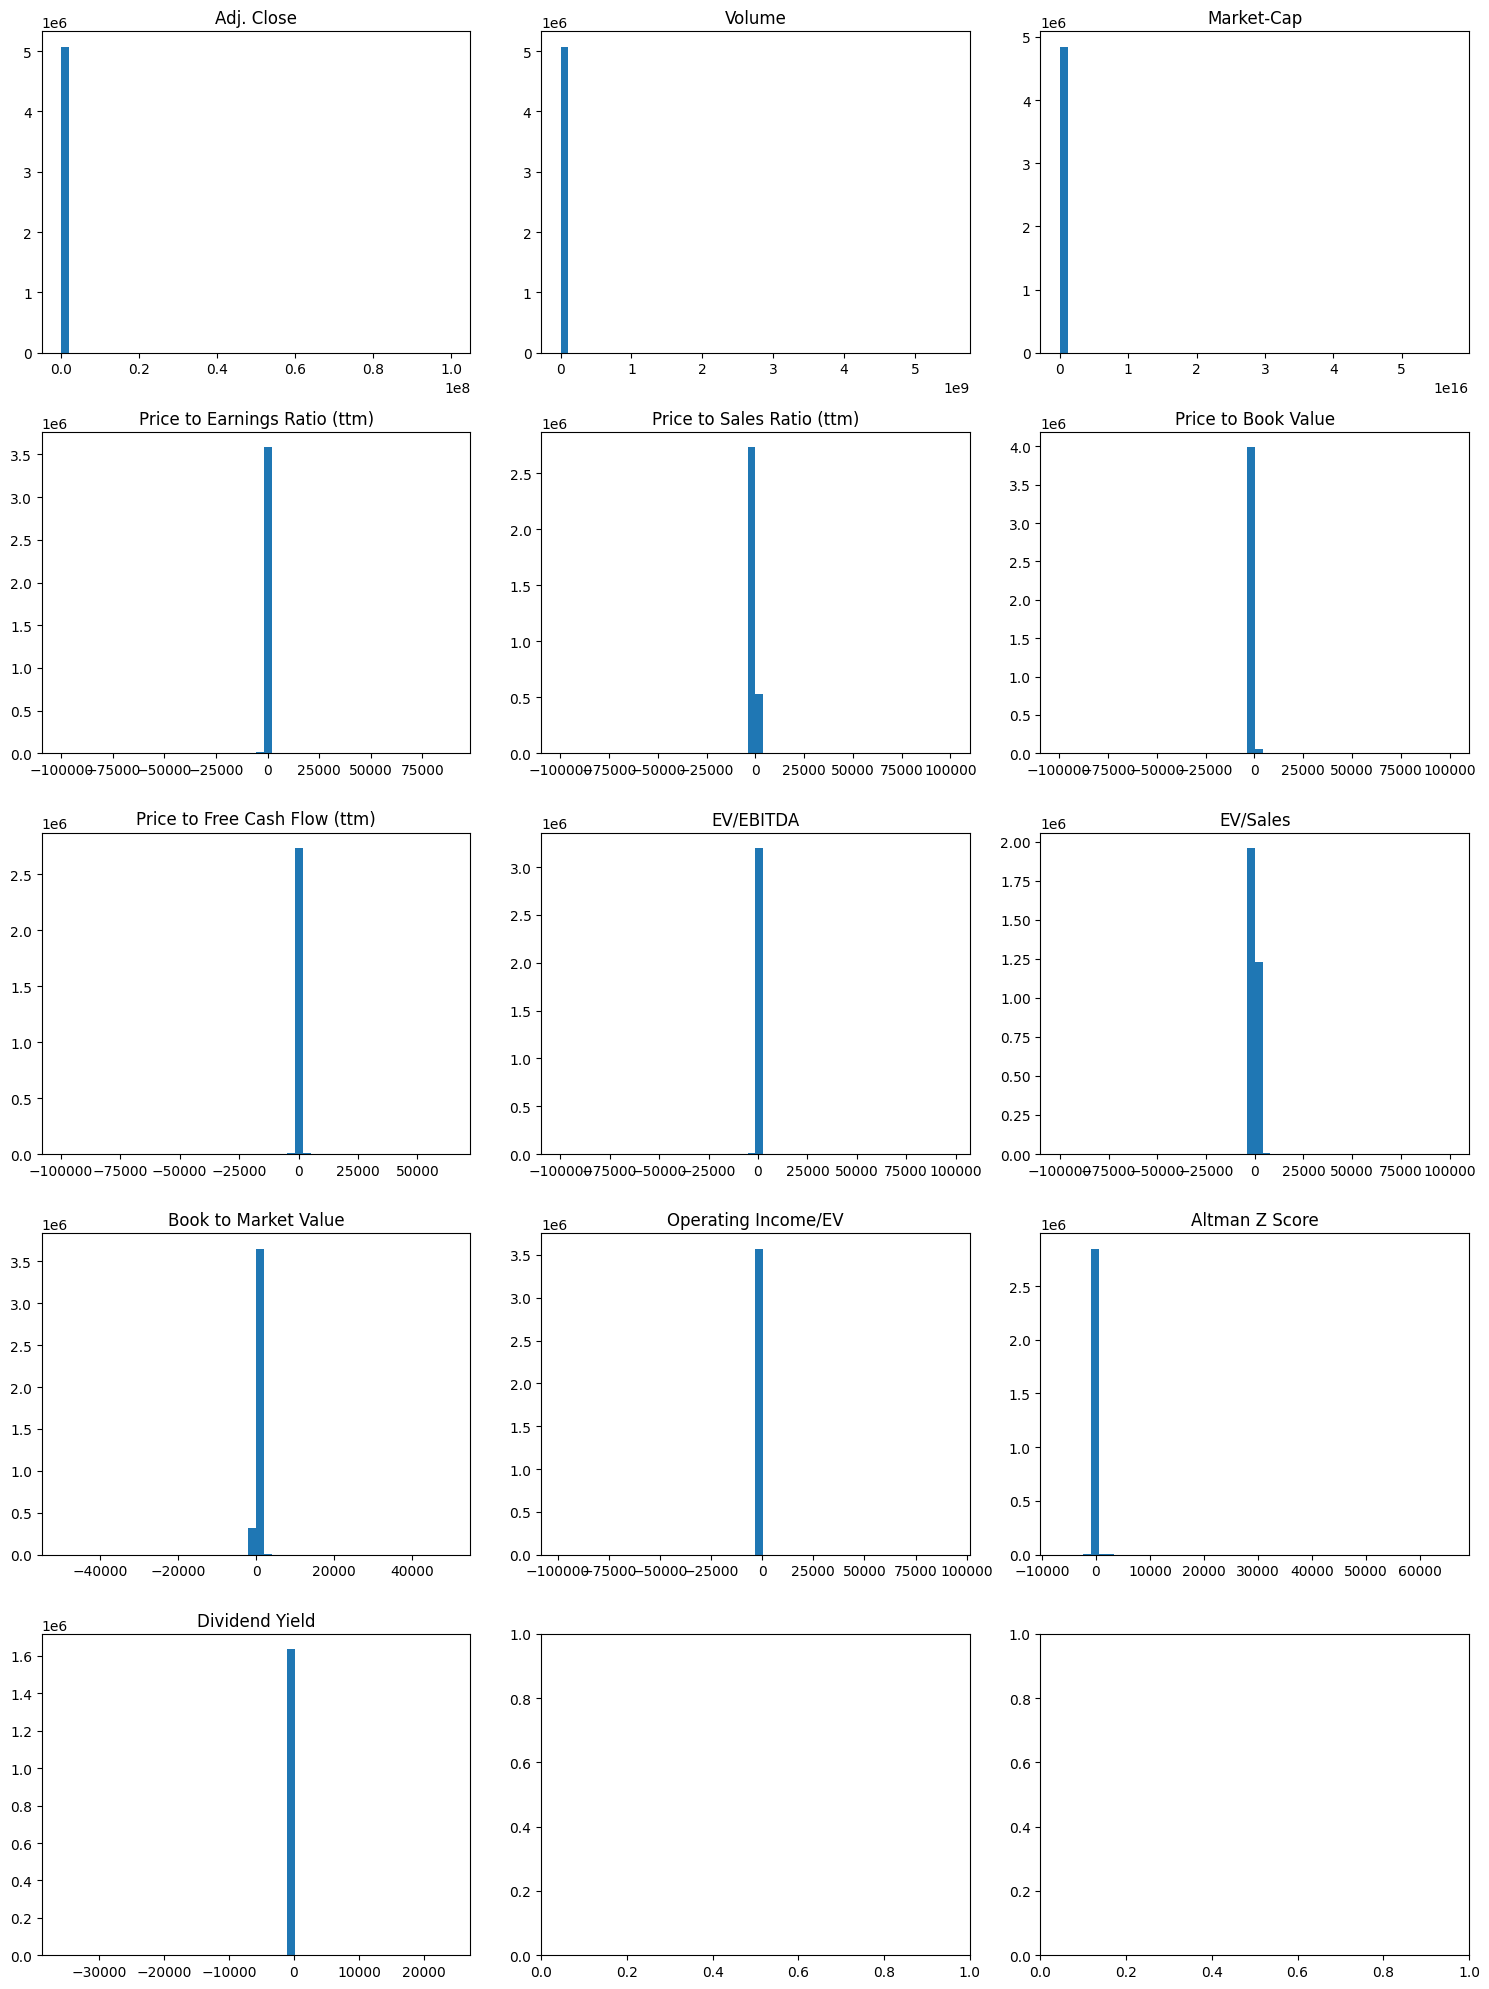

In [10]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    axes[i].hist(
        clean_df[col].dropna(),
        bins=50
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

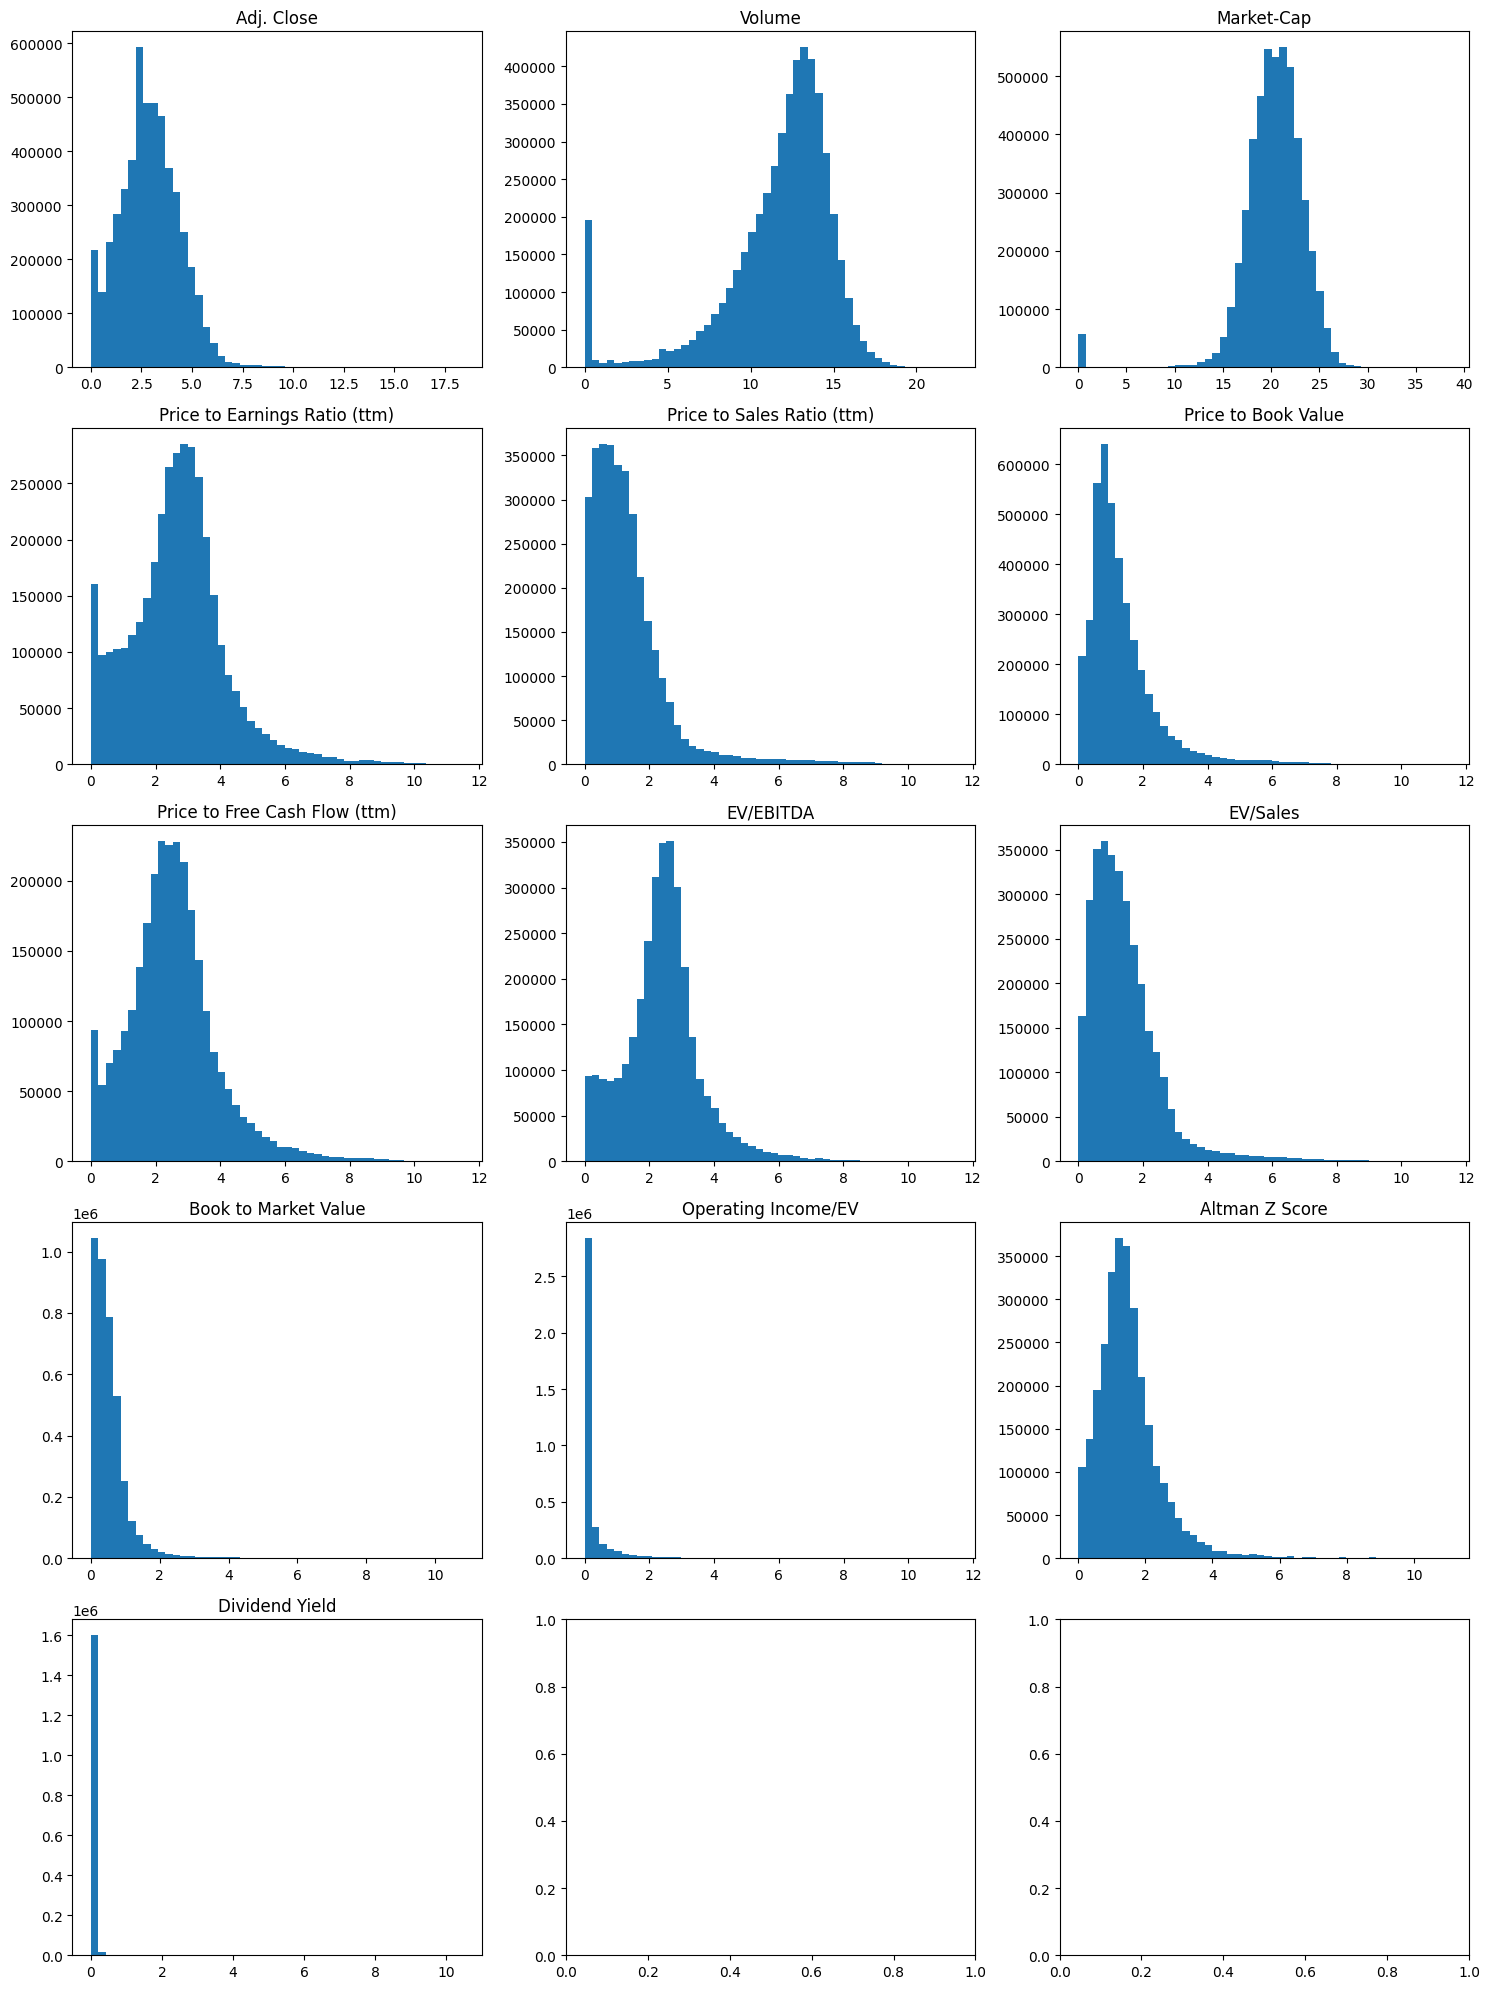

In [11]:
import numpy as np

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    data = clean_df[col].dropna()

    axes[i].hist(
        np.log1p(np.abs(data)),
        bins=50
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

To further investigate the dataset, the feature distributions were visualised using logarithmic scaling since normal distributions don't give any insight.

Although the logarithmic transformation improved the visibility of the distributions, many features still exhibited strong right-skewed distributions and long tails. This indicates that the dataset remains heavily influenced by extreme observations even after placeholder removal and logarithmic scaling.

Above you can see difference in the graphs distributions from the dataframe before and after the cleaning and selection. There are a couple of valuable observations, of weird behaviour.

1. We can see that the range of values dramatically decreases

2. We can see alot of features are heavily skewed which is normal and inline with what we expected.

3. Ideally we would like to see even curves in the graphs indicating a spreaded distribitution. However in some features graphs we still see some unexplainable fluctuations that require further investigation. Like drops around the 0 value.

4. This is also strange since for some graphs we wouldn't expect 0 values but they still contain them and some of them quite alot.

# Time series Analysis

Before further preprocessing and model development, a time series analysis was performed on the selected features. The purpose of this analysis was to investigate whether missing values, outliers, and feature distributions were randomly distributed throughout the dataset or whether they exhibited temporal patterns. Understanding these patterns is important because financial markets are influenced by changing economic conditions, such as market crashes, periods of growth, and major events. If data quality issues or extreme values are concentrated in specific time periods, this may influence preprocessing decisions and model performance.

In [12]:
clean_df["Month"] = (
    pd.to_datetime(clean_df["Date"])
    .dt.to_period("M")
    .astype(str)
)

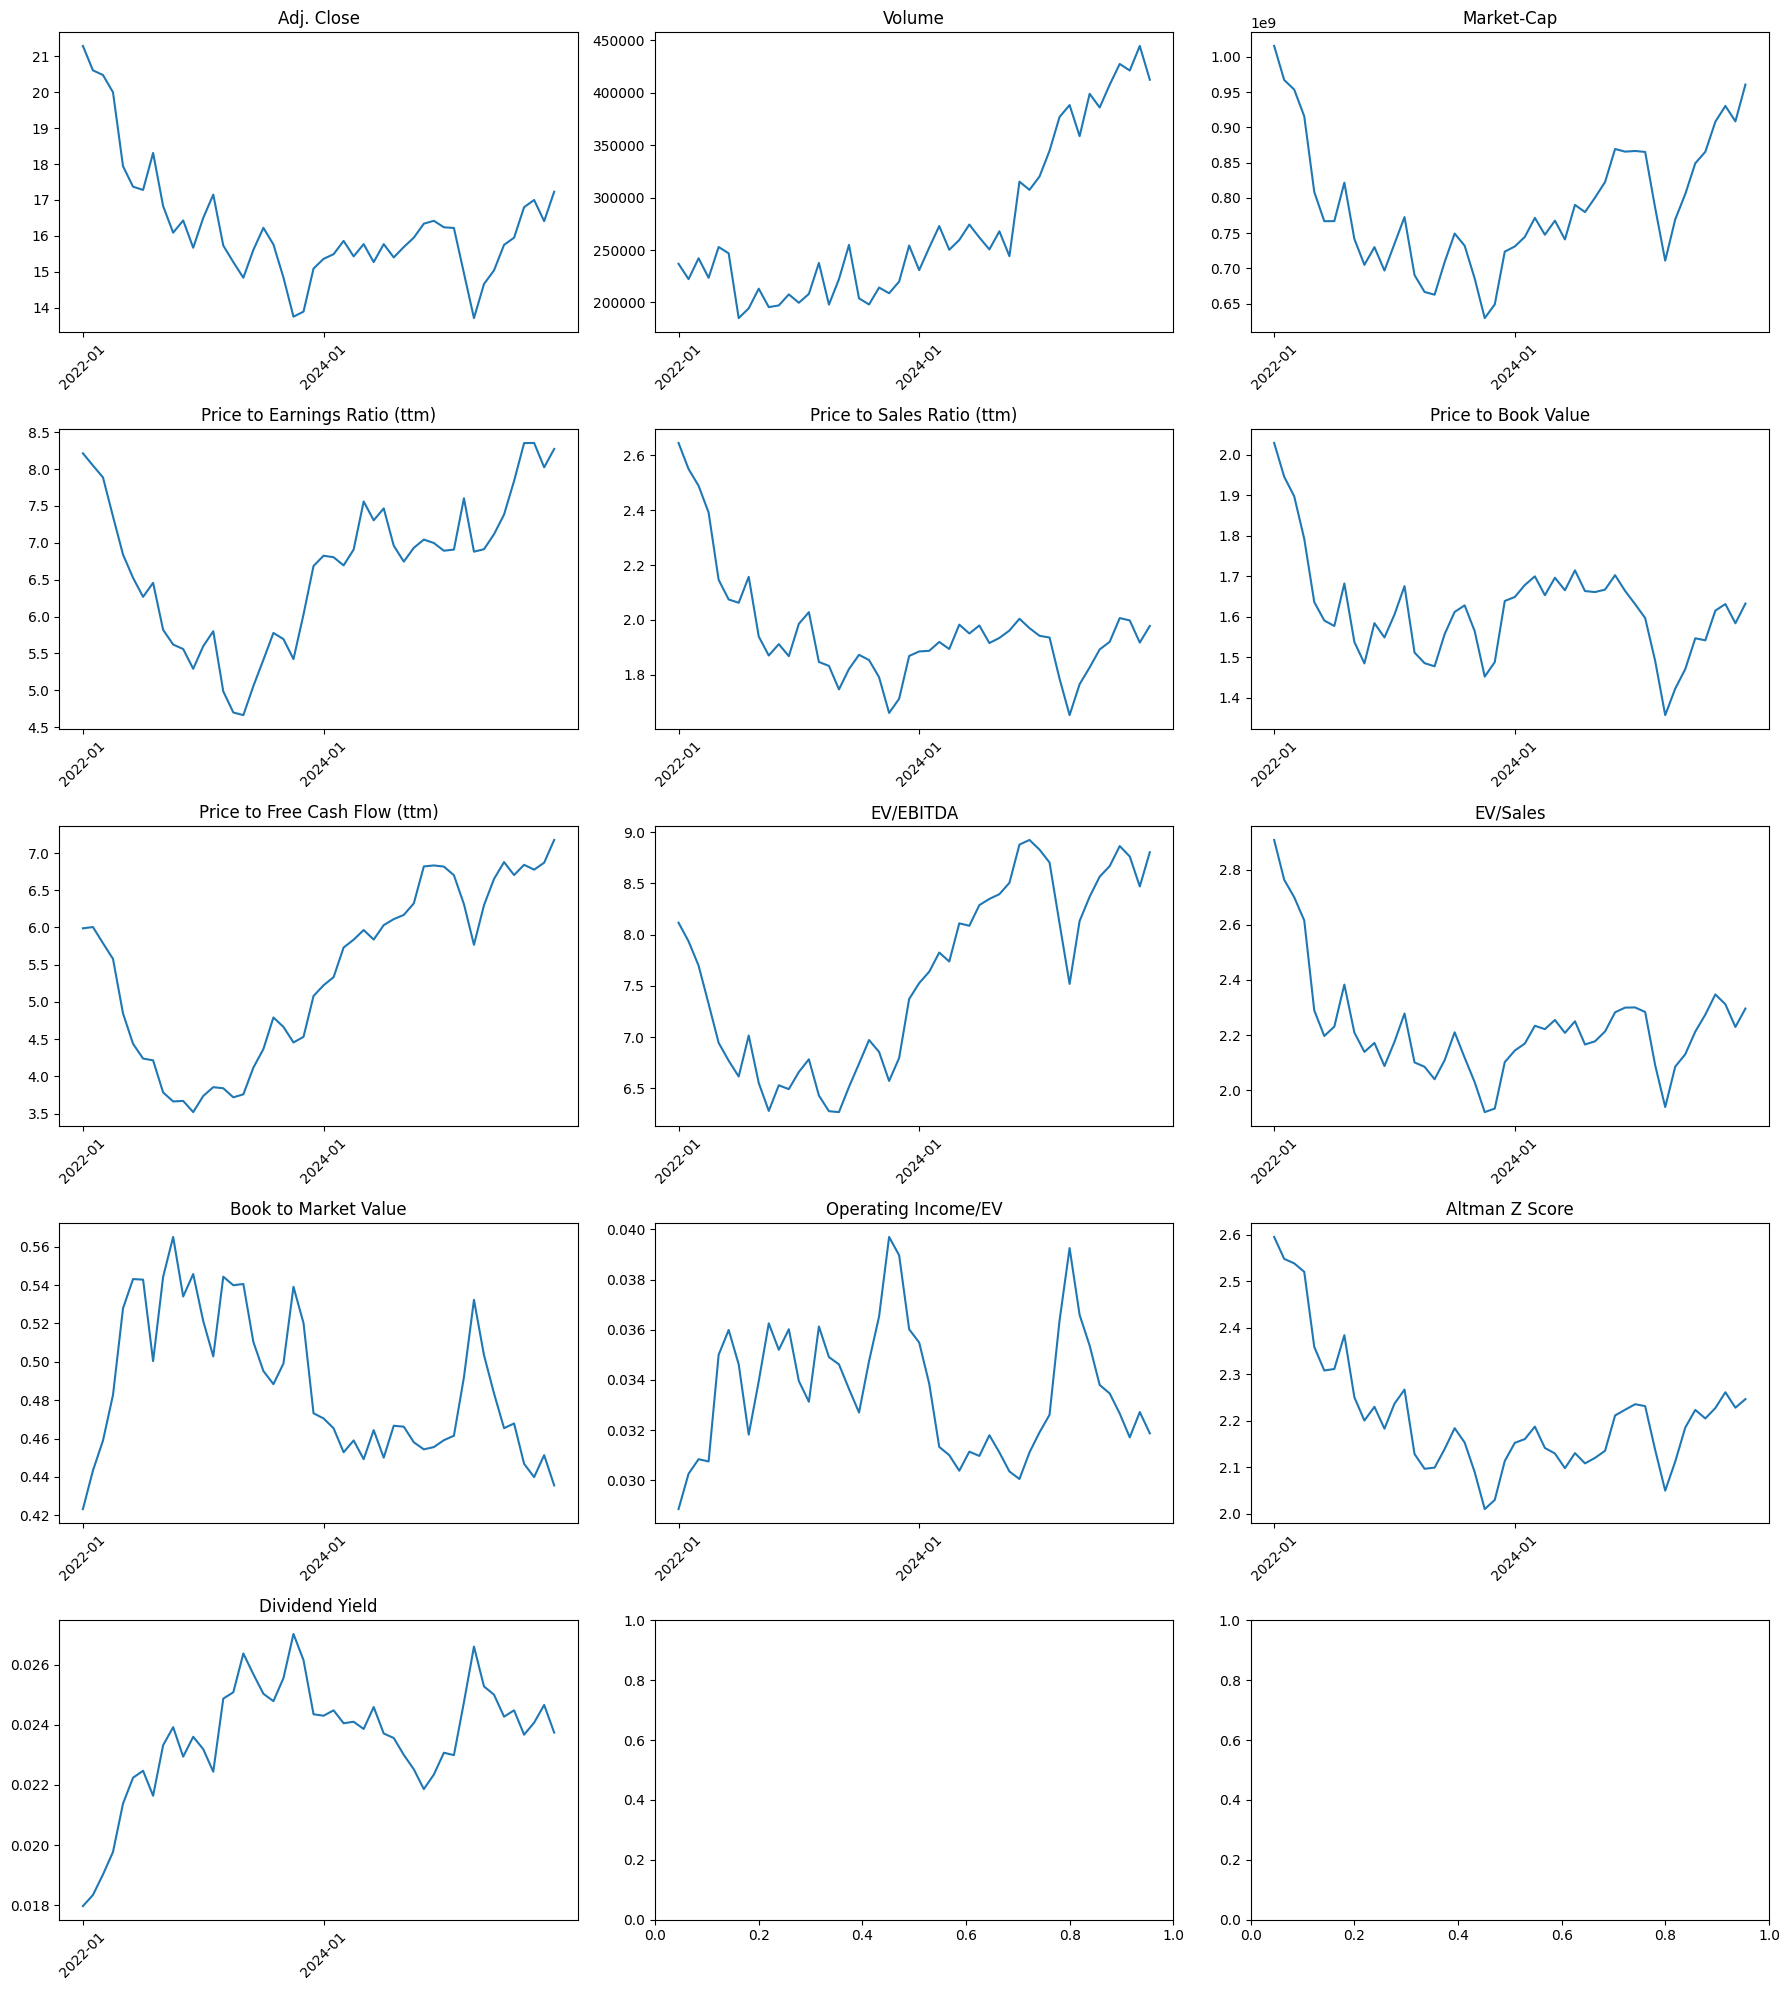

In [13]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    monthly_values = (
        clean_df
        .groupby("Month")[col]
        .median()
    )

    axes[i].plot(
        monthly_values.index,
        monthly_values.values
    )

    axes[i].set_title(col)

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

    axes[i].set_xticks(
        range(0, len(monthly_values), 24)
    )

plt.tight_layout()
plt.show()

Several valuation ratios exhibited substantial temporal trends. Features such as P/E, P/FCF, and EV/EBITDA showed similar movements over time, suggesting that the dataset captures changing market conditions rather than purely random variation.

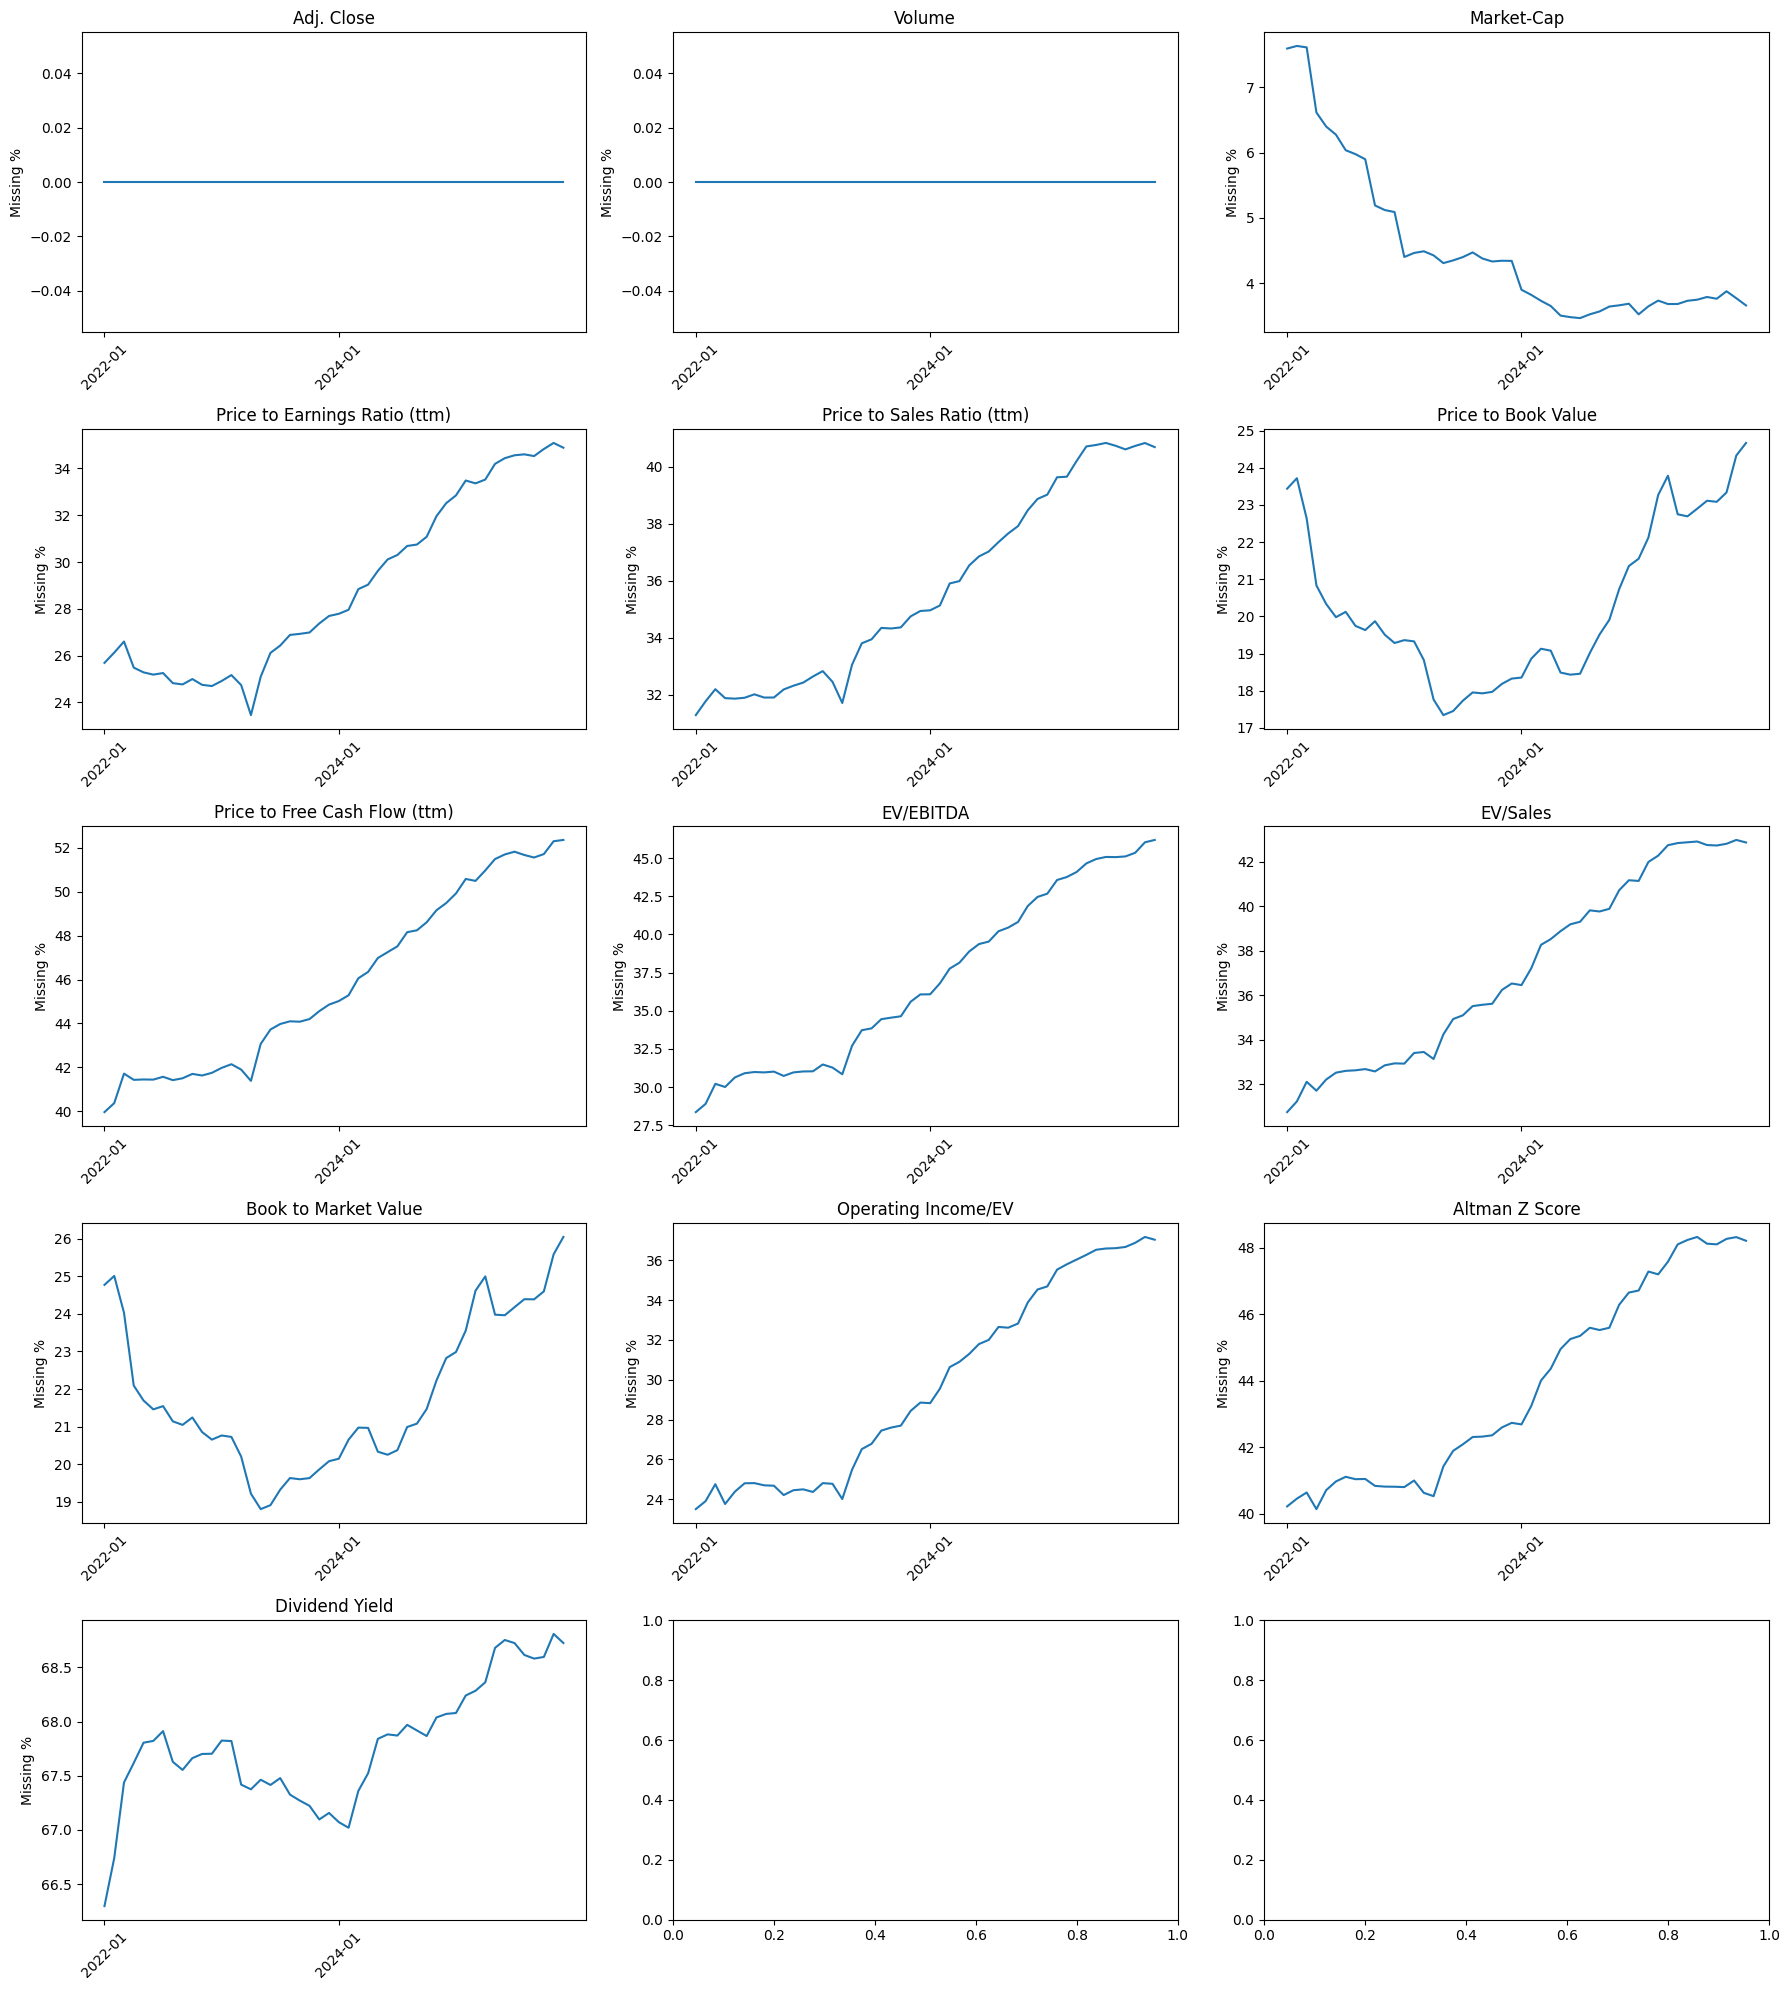

In [14]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    monthly_missing = (
        clean_df
        .groupby("Month")[col]
        .apply(
            lambda x:
            x.isna().mean() * 100
        )
    )

    axes[i].plot(
        monthly_missing.index,
        monthly_missing.values
    )

    axes[i].set_title(col)

    axes[i].set_ylabel("Missing %")

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

    axes[i].set_xticks(
        range(0, len(monthly_missing), 24)
    )

plt.tight_layout()
plt.show()

Missing values were not randomly distributed throughout the dataset. Multiple financial ratios showed a systematic increase in missingness over time, indicating that data availability varies across the observation period.

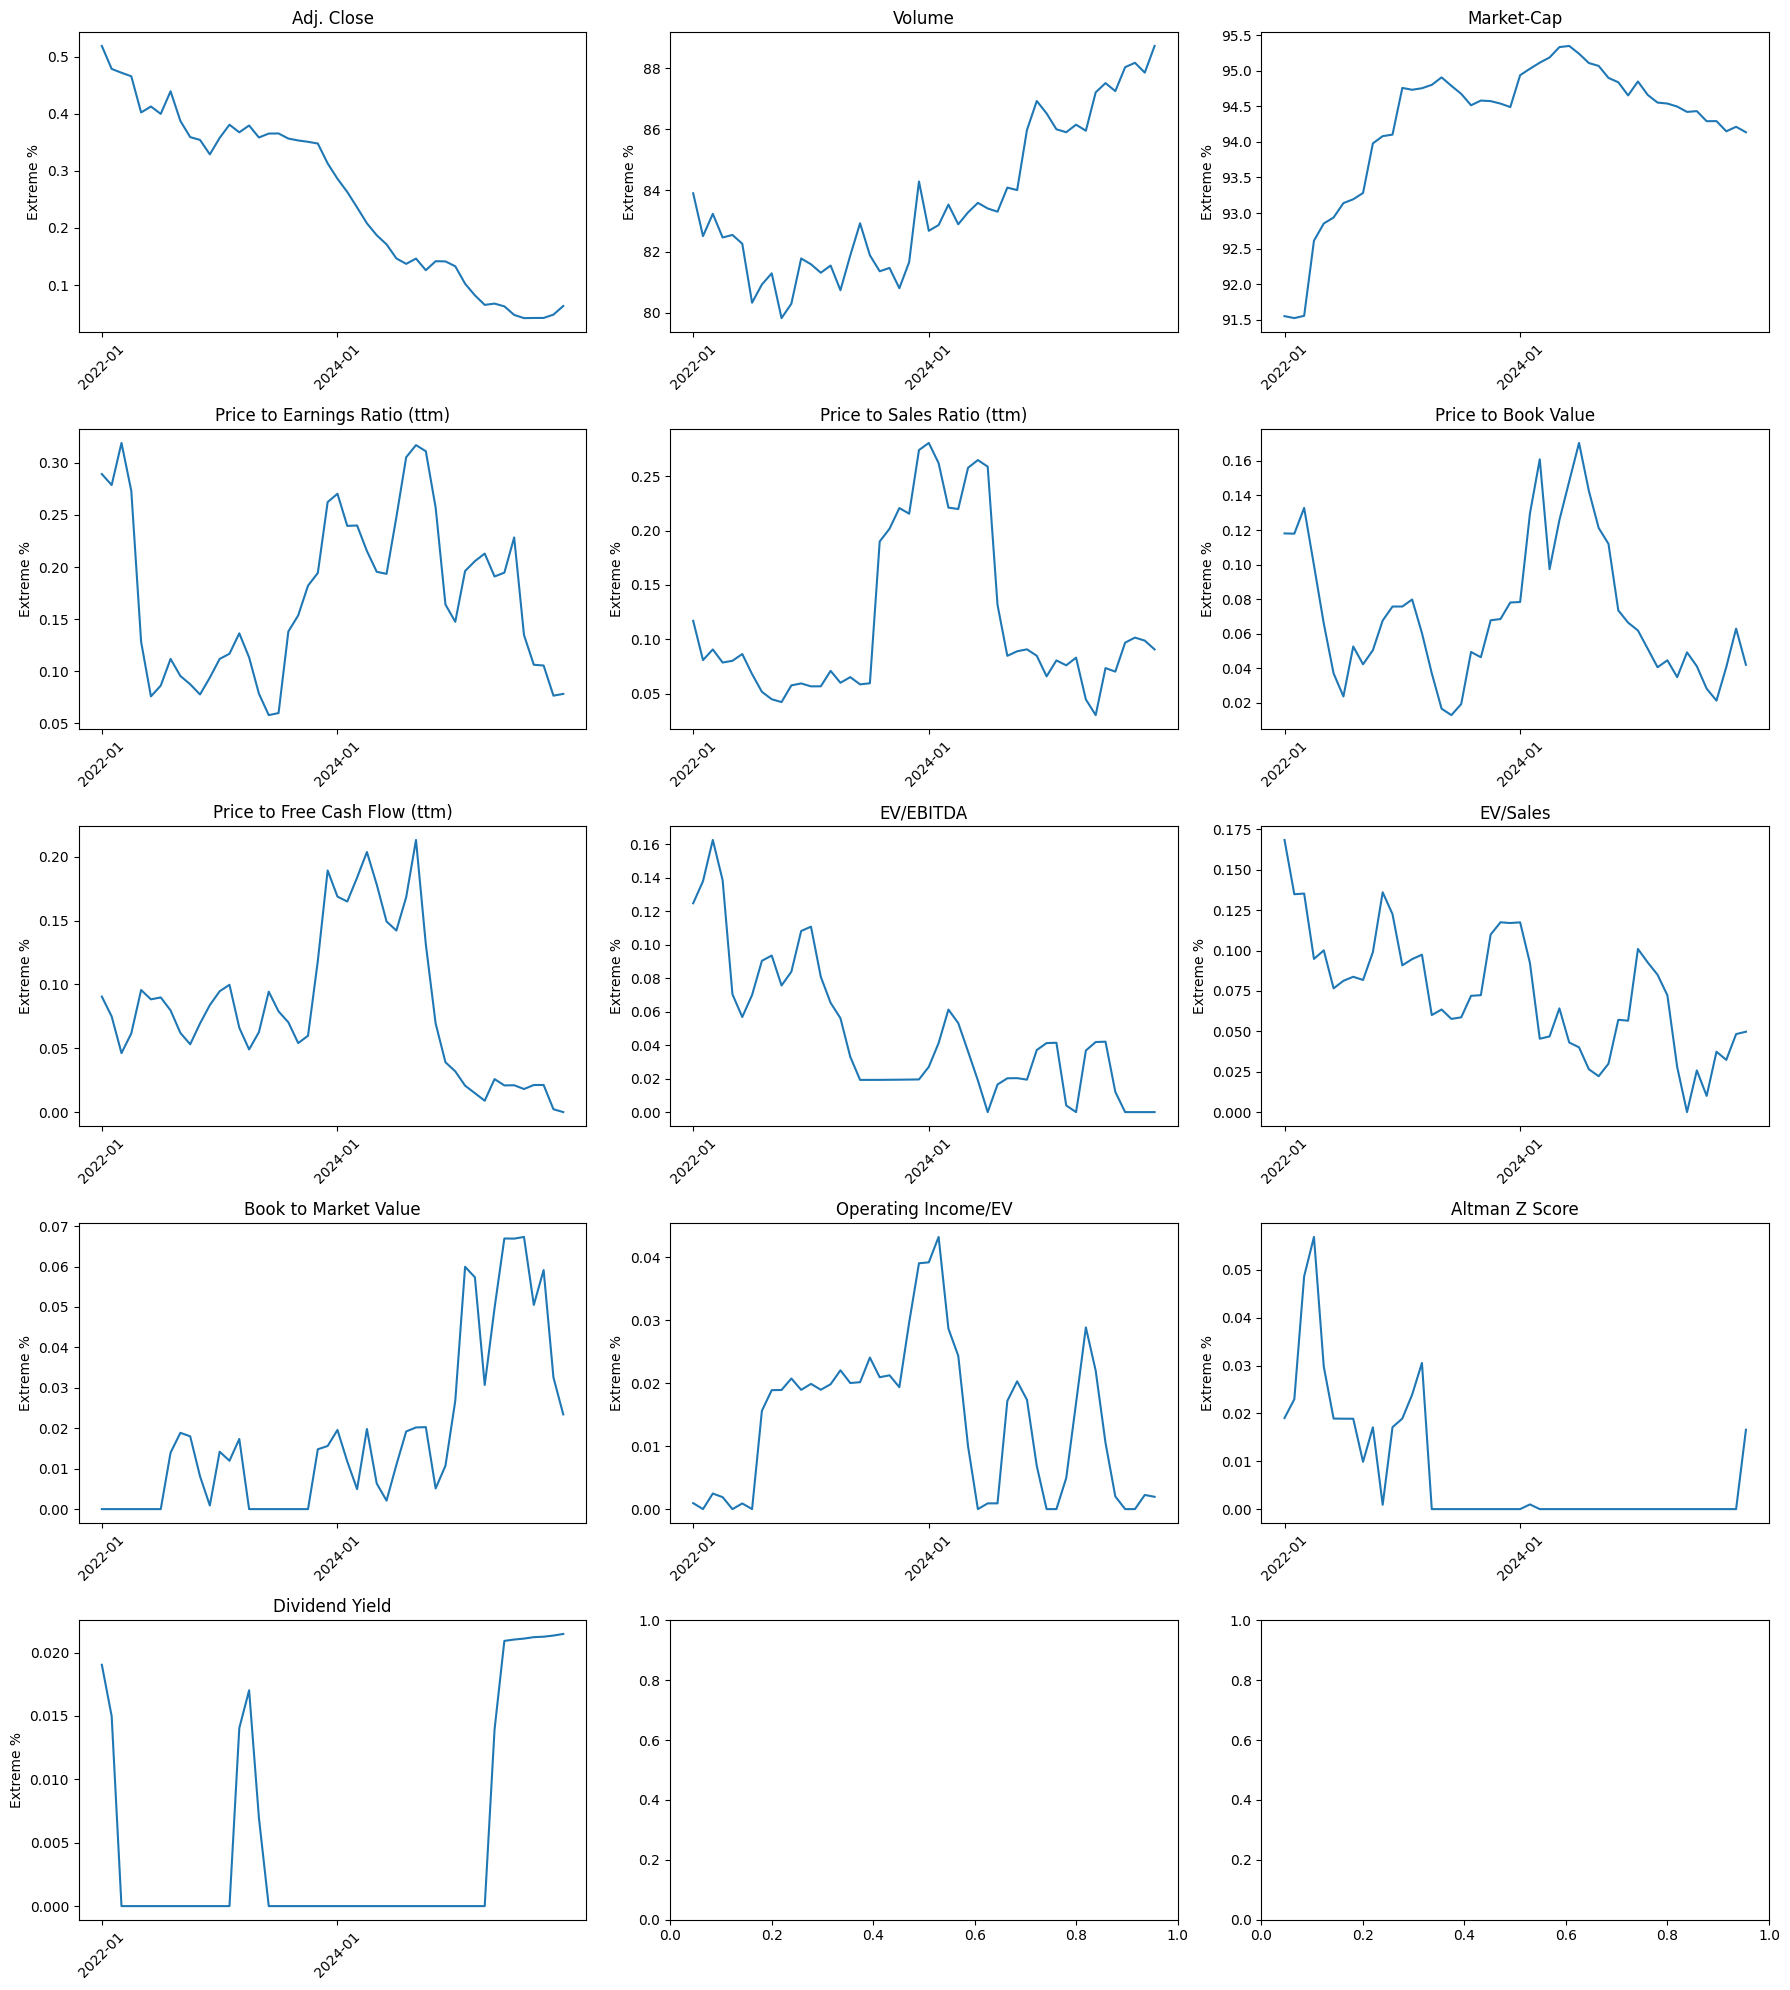

In [15]:
extreme_threshold = 10000

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    monthly_extremes = (
        clean_df
        .groupby("Month")[col]
        .apply(
            lambda x:
            (x.abs() > extreme_threshold)
            .mean() * 100
        )
    )

    axes[i].plot(
        monthly_extremes.index,
        monthly_extremes.values
    )

    axes[i].set_title(col)

    axes[i].set_ylabel("Extreme %")

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

    axes[i].set_xticks(
        range(0, len(monthly_extremes), 24)
    )

plt.tight_layout()
plt.show()

The time series analysis did not reveal any sufficiently strong temporal patterns in the occurrence of extreme values to justify time-based filtering. While some features showed a slight decrease in the percentage of extreme observations over time, these changes remained relatively small and inconsistent. Furthermore, the median feature analysis suggested that several valuation ratios followed broader market trends rather than indicating data quality issues. Therefore, no temporal filtering was applied.

Although the values were not confirmed data errors, the distribution analysis showed that a small number of observations still had a disproportionate influence on multiple features. As a result, percentile-based cleaning was selected as the most appropriate approach. The acceptable ranges for each feature will be determined individually by combining percentile analysis with domain understanding. This allows economically unrealistic observations that provide little value to a value-investing analyst to be identified while retaining observations that represent genuine market behaviour.


| Feature                       | Expected Useful Range |
| ----------------------------- | --------------------- |
| Adj. Close                    | 1 - 50000             |
| Volume                        | 1000 - 50.000.000     |
| Market-cap                    | 10mln - no limit      |
| Price to Earnings Ratio (ttm) | 0 - 100               |
| Price to Sales Ratio (ttm)    | 0 - 50                |
| Price to Book Value           | 0 - 20                |
| Price to Free Cash Flow (ttm) | 0 - 100               |
| EV/EBITDA                     | 0 - 50                |
| EV/Sales                      | 0 - 30                |
| Book to Market Value          | -10 - 10              |
| Operating Income/EV           | -5 - 5                |
| Altman Z Score                | -10 - 20              |
| Dividend Yield                | 0 - 20%               |

Based on the stakeholder interview, the selected ratios were identified as important indicators for value investing. To assess whether the remaining extreme observations were useful for the intended application, expected value ranges were defined using value investing domain knowledge. These ranges do not represent strict financial limits but provide an indication of values that remain meaningful for investment analysis. Values far outside these ranges are unlikely to provide useful information to a value-investing analyst and may indicate extreme denominator effects or unusual financial situations.

In [16]:
market_cap_max = clean_df["Market-Cap"].max()

domain_ranges = {
    "Adj. Close": (1, 5000),
    "Volume": (1000, 50000000),
    "Market-Cap": (10000000, market_cap_max),
    "Price to Earnings Ratio (ttm)": (0, 100),
    "Price to Sales Ratio (ttm)": (0, 50),
    "Price to Book Value": (0, 20),
    "Price to Free Cash Flow (ttm)": (0, 100),
    "EV/EBITDA": (0, 50),
    "EV/Sales": (0, 30),
    "Book to Market Value": (-10, 10),
    "Operating Income/EV": (-5, 5),
    "Altman Z Score": (-10, 20),
    "Dividend Yield": (0, 20)
}

percentiles = [
    0.001,
    0.005,
    0.01,
    0.025,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.975,
    0.99,
    0.995,
    0.999
]

clean_df[list(domain_ranges.keys())] \
    .quantile(percentiles) \
    .T

,0.001,0.005,0.010,0.025,0.050,0.100,0.250,0.500,0.750,0.900,0.950,0.975,0.990,0.995,0.999
Adj. Close,0.000000,0.000000,0.000000,1.000000e-01,6.400000e-01,1.700000e+00,5.780000e+00,1.626000e+01,4.615000e+01,1.195100e+02,2.049200e+02,3.346800e+02,7.075434e+02,2.560511e+03,4.325612e+05
Volume,0.000000,0.000000,0.000000,0.000000e+00,5.000000e+01,2.036000e+03,3.290600e+04,2.620240e+05,1.039564e+06,3.060498e+06,6.014906e+06,1.100544e+07,2.323762e+07,3.921792e+07,1.029897e+08
Market-Cap,0.000000,0.000000,0.000000,2.298252e+06,8.795970e+06,2.599549e+07,1.301741e+08,7.850186e+08,4.506176e+09,2.087576e+10,5.184526e+10,1.030287e+11,2.137250e+11,3.716949e+11,1.989423e+12
Price to Earnings Ratio (ttm),-12807.329363,-1935.422130,-841.206510,-2.212809e+02,-7.731156e+01,-2.435477e+01,-3.792040e+00,6.455550e+00,2.125608e+01,4.325139e+01,7.718415e+01,1.557241e+02,5.074736e+02,1.324751e+03,1.118495e+04
Price to Sales Ratio (ttm),-42.649428,0.000000,0.000000,3.105000e-02,1.218700e-01,2.698600e-01,7.372800e-01,1.951320e+00,4.583095e+00,1.141810e+01,2.932875e+01,1.433140e+02,1.011740e+03,2.768166e+03,1.968199e+04
Price to Book Value,-2057.120166,-142.226675,-53.615380,-1.234403e+01,-2.090692e+00,7.356000e-02,7.867000e-01,1.616320e+00,3.642320e+00,8.633150e+00,1.747618e+01,4.621846e+01,3.026059e+02,7.385309e+02,4.666409e+03
Price to Free Cash Flow (ttm),-8481.709570,-1298.587852,-517.723378,-1.409243e+02,-5.961795e+01,-2.202527e+01,-2.930705e+00,5.294250e+00,1.524490e+01,3.377737e+01,6.556260e+01,1.470461e+02,4.719977e+02,1.091539e+03,8.223932e+03
EV/EBITDA,-4256.528490,-561.345123,-239.786830,-7.836947e+01,-3.122171e+01,-1.118434e+01,-7.296450e-01,7.518600e+00,1.497546e+01,2.676072e+01,4.661867e+01,8.649170e+01,2.249012e+02,4.842779e+02,3.060033e+03
EV/Sales,-488.198500,-30.568454,-9.075959,-1.034185e+00,6.348000e-02,3.252900e-01,8.752500e-01,2.219940e+00,5.216317e+00,1.191139e+01,2.266802e+01,7.614818e+01,4.605636e+02,1.354917e+03,9.806614e+03
Book to Market Value,-222.717150,-10.434060,-3.285470,-6.170450e-01,-1.068100e-01,1.441000e-02,1.875200e-01,4.889400e-01,9.736900e-01,1.732830e+00,2.917070e+00,5.297170e+00,2.060496e+01,1.216545e+02,1.851852e+03


Now based on our stakeholder ranges. We can manually select the closest upper and bottom percentiles to our ranges.

In [17]:
feature_percentiles = {
    "Adj. Close": (0.025, 0.995),
    "Volume": (0.10, 0.995),
    "Market-Cap": (0.05, 1.0),
    "Price to Earnings Ratio (ttm)": (0.05, 0.95),
    "Price to Sales Ratio (ttm)": (0.05, 0.95),
    "Price to Book Value": (0.10, 0.95),
    "Price to Free Cash Flow (ttm)": (0.05, 0.95),
    "EV/EBITDA": (0.05, 0.95),
    "EV/Sales": (0.025, 0.95),
    "Book to Market Value": (0.005, 0.975),
    "Operating Income/EV": (0.01, 0.99),
    "Altman Z Score": (0.01, 0.975),
    "Dividend Yield": (0.005, 0.995)
}

In [18]:
impact = []

for col, (lower_pct, upper_pct) in feature_percentiles.items():

    lower = clean_df[col].quantile(lower_pct)
    upper = clean_df[col].quantile(upper_pct)

    mask = (
        (clean_df[col] < lower) |
        (clean_df[col] > upper)
    )

    impact.append({
        "Feature": col,
        "Lower Percentile": lower_pct,
        "Upper Percentile": upper_pct,
        "Lower Value": lower,
        "Upper Value": upper,
        "Rows Removed": mask.sum(),
        "% Removed": mask.mean() * 100
    })

impact_df = pd.DataFrame(impact)

impact_df.sort_values(
    "% Removed",
    ascending=False
)

,Feature,Lower Percentile,Upper Percentile,Lower Value,Upper Value,Rows Removed,% Removed
5,Price to Book Value,0.100,0.950,7.356000e-02,1.747618e+01,607142,11.958151
1,Volume,0.100,0.995,2.036000e+03,3.921792e+07,533095,10.499736
3,Price to Earnings Ratio (ttm),0.050,0.950,-7.731156e+01,7.718415e+01,361800,7.125943
4,Price to Sales Ratio (ttm),0.050,0.950,1.218700e-01,2.932875e+01,327102,6.442538
7,EV/EBITDA,0.050,0.950,-3.122171e+01,4.661867e+01,321196,6.326214
6,Price to Free Cash Flow (ttm),0.050,0.950,-5.961795e+01,6.556260e+01,275730,5.430725
2,Market-Cap,0.050,1.000,8.795970e+06,5.698460e+16,242343,4.773141
8,EV/Sales,0.025,0.950,-1.034185e+00,2.266802e+01,239888,4.724788
0,Adj. Close,0.025,0.995,1.000000e-01,2.560511e+03,151635,2.986574
9,Book to Market Value,0.005,0.975,-1.043406e+01,5.297170e+00,119026,2.344313


In [19]:
final_df = clean_df.copy()

for col, (lower_pct, upper_pct) in feature_percentiles.items():

    lower = final_df[col].quantile(lower_pct)
    upper = final_df[col].quantile(upper_pct)

    final_df.loc[
        (final_df[col] < lower) |
        (final_df[col] > upper),
        col
    ] = np.nan

print(final_df.shape)

(5077223, 16)


In [20]:
missing_before = clean_df.isna().mean() * 100
missing_after = final_df.isna().mean() * 100

missing_comparison = pd.DataFrame({
    "Missing Before (%)": missing_before,
    "Missing After (%)": missing_after,
    "Increase (%)": missing_after - missing_before
})

missing_comparison.sort_values(
    "Increase (%)",
    ascending=False
)

,Missing Before (%),Missing After (%),Increase (%)
Price to Book Value,20.276498,32.234649,11.958151
Volume,0.000000,10.499736,10.499736
Price to Earnings Ratio (ttm),28.740613,35.866555,7.125943
Price to Sales Ratio (ttm),35.573620,42.016157,6.442538
EV/EBITDA,36.738036,43.064250,6.326214
Price to Free Cash Flow (ttm),45.693089,51.123813,5.430725
Market-Cap,4.537480,9.310621,4.773141
EV/Sales,37.003003,41.727791,4.724788
Adj. Close,0.000000,2.986574,2.986574
Book to Market Value,21.771784,24.116097,2.344313


Domain-driven percentile thresholds were applied to remove economically unrealistic observations. This resulted in the removal of approximately 28% of the dataset. Although substantial, the cleaning process significantly improved the feature distributions and revealed stronger relationships between the financial ratios and stock prices.

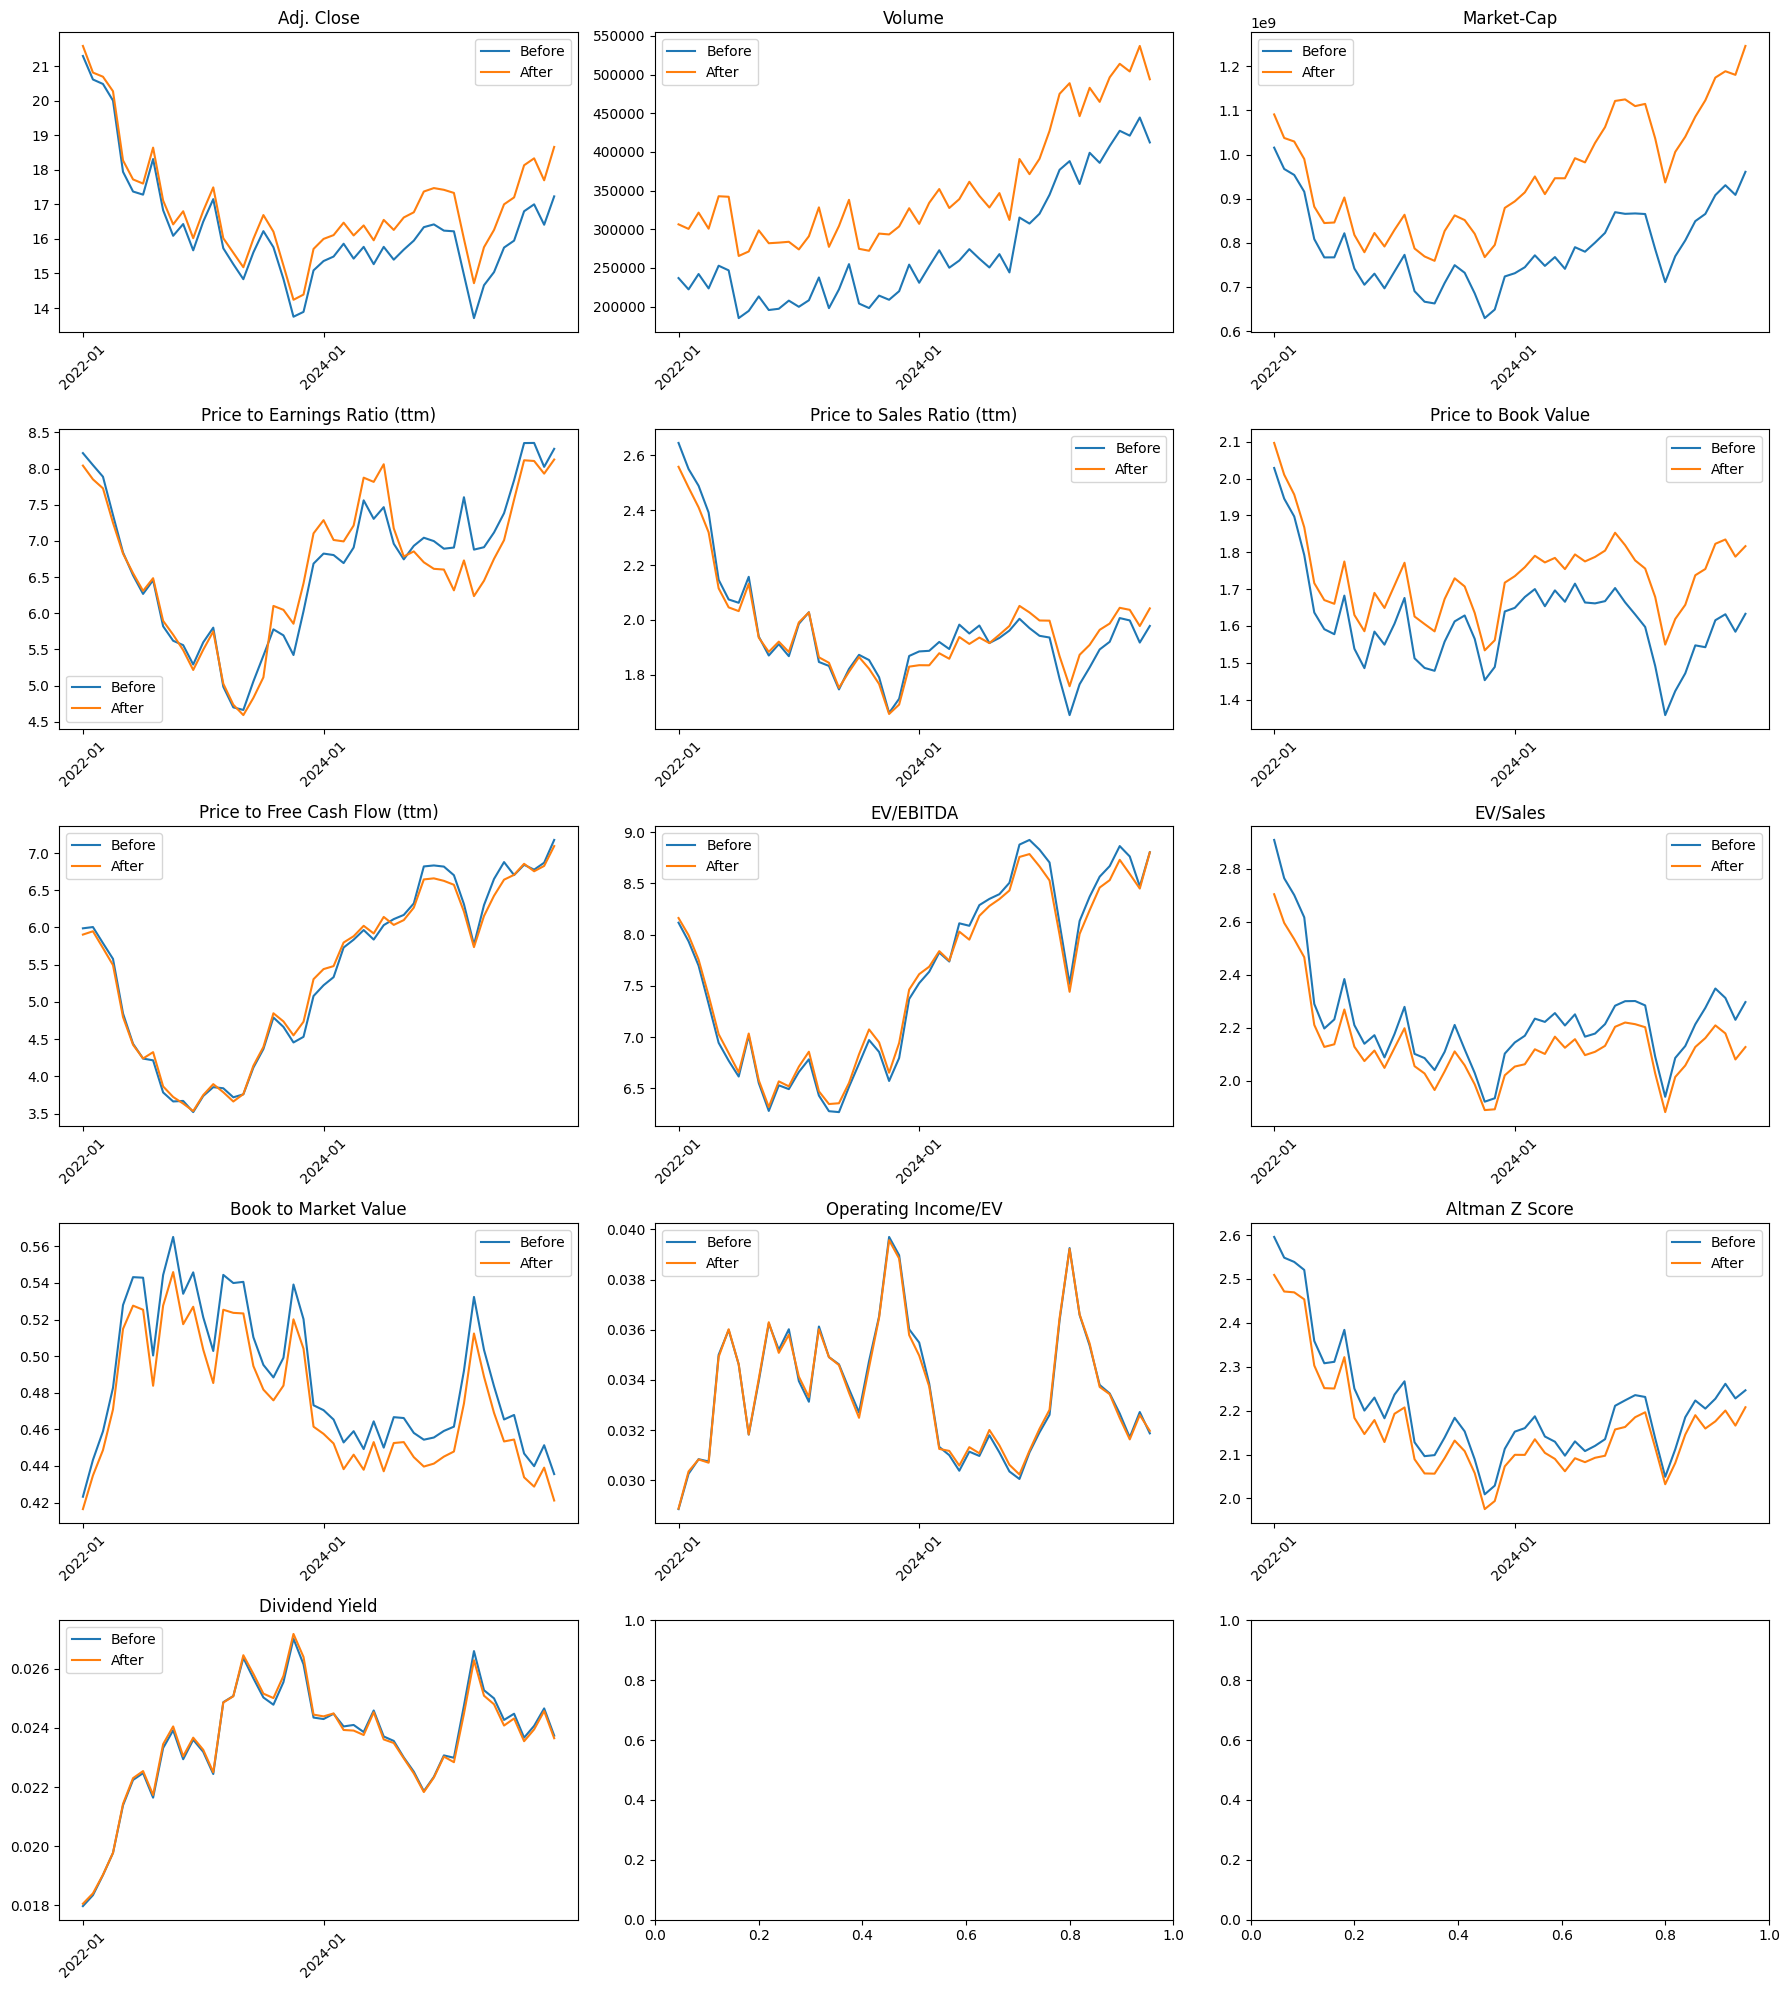

In [21]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    before = (
        clean_df
        .groupby("Month")[col]
        .median()
    )

    after = (
        final_df
        .groupby("Month")[col]
        .median()
    )

    axes[i].plot(
        before.index,
        before.values,
        label="Before"
    )

    axes[i].plot(
        after.index,
        after.values,
        label="After"
    )

    axes[i].set_title(col)

    axes[i].tick_params(
        axis="x",
        rotation=45
    )

    axes[i].set_xticks(
        range(0, len(before), 24)
    )

    axes[i].legend()

plt.tight_layout()
plt.show()

Although the temporal trends remained largely unchanged after cleaning, the median values of several features increased noticeably. This indicates that the cleaning process primarily removed observations with extreme negative values and incomplete financial information. Furthermore, the median Market Capitalization, Volume and Stock Price increased substantially after row removal, suggesting that larger and more established companies generally contained more complete financial information than smaller firms. This should be considered when interpreting the final dataset.

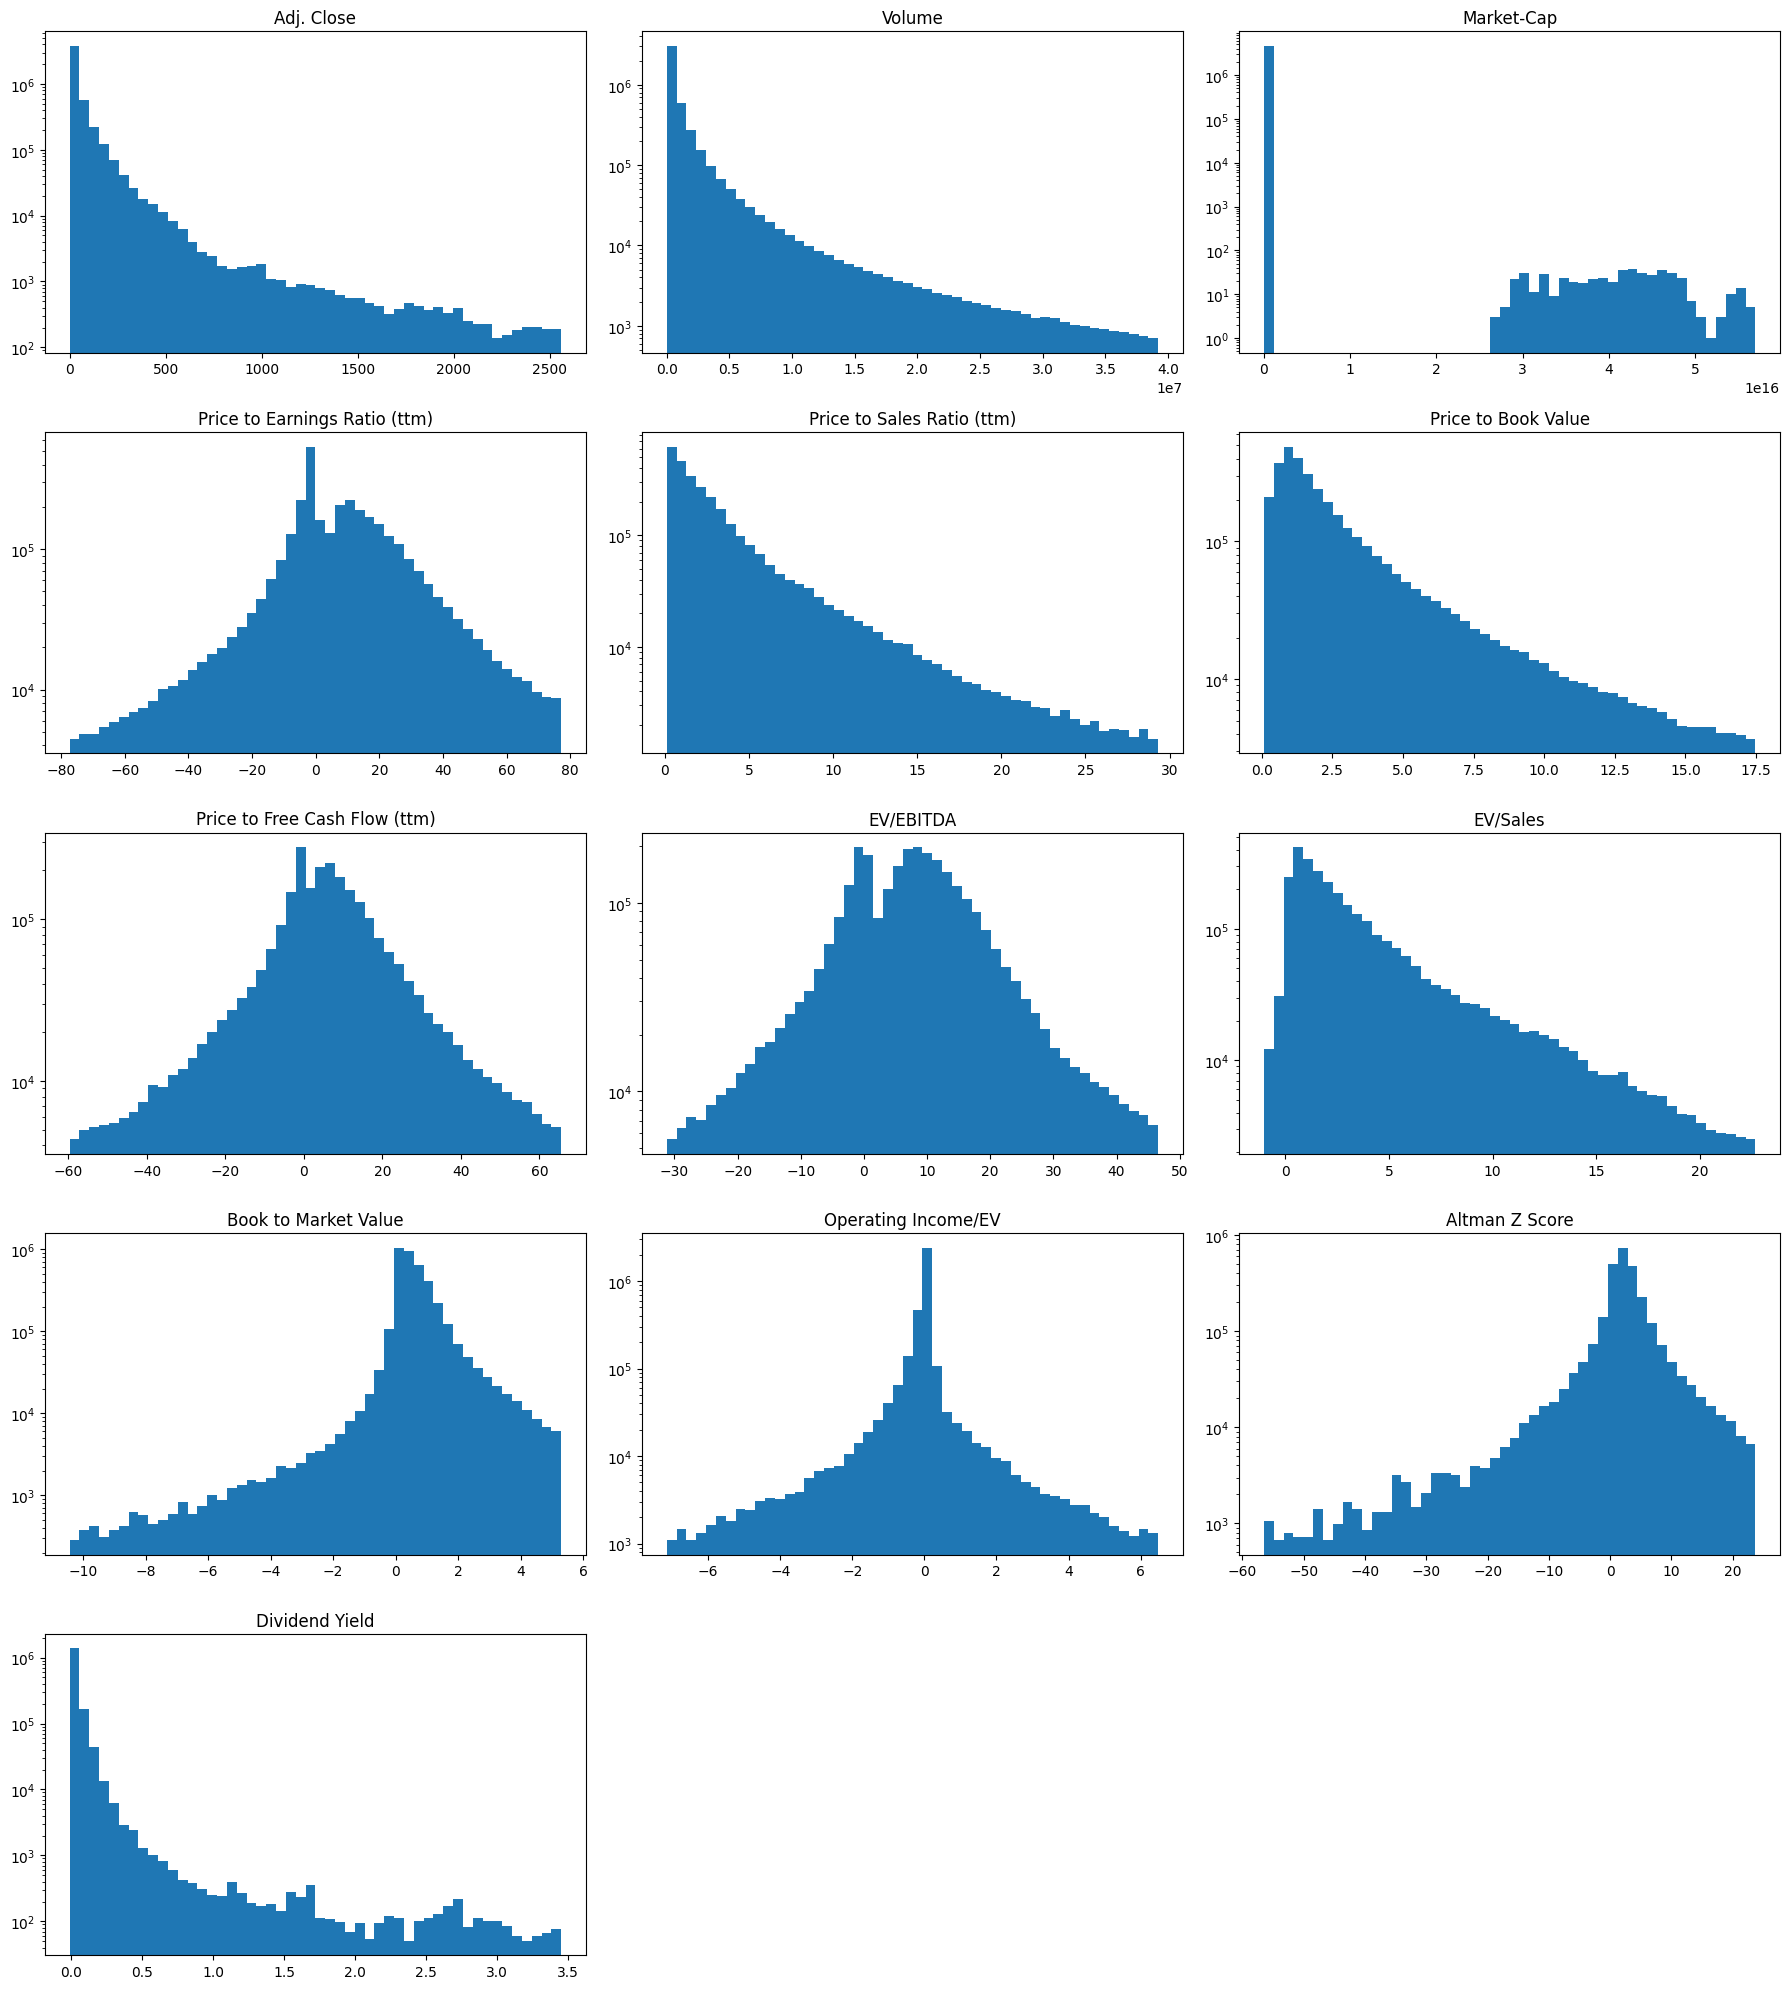

In [22]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    axes[i].hist(
        final_df[col].dropna(),
        bins=50
    )

    axes[i].set_title(col)

    axes[i].set_yscale("log")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The final distributions indicate that the placeholder values and most extreme observations were successfully removed. While some variables such as stock price, trading volume and market capitalization remain positively skewed due to their natural financial characteristics, the valuation ratios now exhibit substantially more concentrated and interpretable distributions. Combined with the observed increase in target correlations, this suggests that the cleaning process reduced noise while preserving meaningful financial relationships.

# Preprocessing

After placeholder removal and percentile-based cleaning, two approaches were considered for handling the remaining missing values. The first option was to remove all incomplete rows from the dataset. While this would result in a fully complete dataset, earlier analysis showed that this approach can substantially alter the composition of the dataset by disproportionately removing certain companies.

The second option was to evaluate data completeness at the company level and select only companies that maintain a high percentage of complete observations. This approach aligns with the strategy explored during the baseline model, where selecting high-quality data proved more effective than repeatedly applying additional cleaning techniques to unreliable observations.

Therefore, company completeness will be analysed to determine an appropriate threshold for inclusion in the final modelling dataset. This allows the final dataset to remain both clean and representative while maintaining a transparent and reproducible selection process.


In [23]:
ratio_cols = [
    "Adj. Close",
    "Volume",
    "Market-Cap",
    "Price to Earnings Ratio (ttm)",
    "Price to Sales Ratio (ttm)",
    "Price to Book Value",
    "Price to Free Cash Flow (ttm)",
    "EV/EBITDA",
    "EV/Sales",
    "Book to Market Value",
    "Operating Income/EV",
    "Altman Z Score",
    "Dividend Yield"
]

ticker_quality = (
    final_df.groupby("Ticker")[ratio_cols]
      .apply(lambda x: x.notna().mean().mean())
      .sort_values(ascending=False)
)

print(ticker_quality)

Ticker
A       1.000000
CAI     1.000000
CASY    1.000000
CAT     1.000000
CBOE    1.000000
          ...   
MULN    0.016566
GLRP    0.000277
SKPN    0.000173
SBNC    0.000000
CYNK    0.000000
Length: 5793, dtype: float64


In [24]:
print("Companies with >= 50% completeness:",
      (ticker_quality >= 0.50).sum())

print("Companies with >= 75% completeness:",
      (ticker_quality >= 0.75).sum())

print("Companies with >= 90% completeness:",
      (ticker_quality >= 0.90).sum())

print("Companies with >= 95% completeness:",
      (ticker_quality >= 0.95).sum())

print("Companies with 100% completeness:",
      (ticker_quality == 1.00).sum())

print("Total companies:", final_df["Ticker"].nunique())

Companies with >= 50% completeness: 4060
Companies with >= 75% completeness: 2718
Companies with >= 90% completeness: 1358
Companies with >= 95% completeness: 651
Companies with 100% completeness: 205
Total companies: 5793


In [25]:
print(ticker_quality.sample(20))

Ticker
OCN      0.639305
ON       0.922847
GSIT     0.921006
XHR      0.981977
ISBA     0.397807
INSP     0.632947
NCNC     0.228083
CCCS     0.852673
BHM      0.307786
LGF-B    0.560217
RSSS     0.740931
ASAN     0.889792
FANG     1.000000
VCRA     0.653846
WRK      1.000000
PRVB     0.692308
GXO      0.915331
EGHT     0.910806
POST     0.783496
CWAN     0.714702
dtype: float64


Here you can see how much difference there is in the dataset in completness of the data per company

In [26]:
good_tickers = ticker_quality[ticker_quality >= 0.90].index

company_filtered_df = final_df[
    final_df["Ticker"].isin(good_tickers)
].copy()

print("Companies:", company_filtered_df["Ticker"].nunique())
print("Rows before final row filtering:", len(company_filtered_df))

Companies: 1358
Rows before final row filtering: 1215754


In [27]:
(company_filtered_df.isnull().sum() / len(company_filtered_df) * 100).sort_values(ascending=False)


Dividend Yield                   29.294166
Altman Z Score                    7.807747
Price to Free Cash Flow (ttm)     6.798415
Price to Book Value               4.960790
Price to Earnings Ratio (ttm)     4.505846
EV/EBITDA                         2.360181
Price to Sales Ratio (ttm)        0.993787
Volume                            0.887186
EV/Sales                          0.719800
Operating Income/EV               0.572978
Book to Market Value              0.560228
Market-Cap                        0.106518
Adj. Close                        0.007485
Ticker                            0.000000
Date                              0.000000
Month                             0.000000
dtype: float64

In [28]:
final_df.isna().mean().sort_values(ascending=False) * 100

Dividend Yield                   68.090549
Price to Free Cash Flow (ttm)    51.123813
Altman Z Score                   45.679873
EV/EBITDA                        43.064250
Price to Sales Ratio (ttm)       42.016157
EV/Sales                         41.727791
Price to Earnings Ratio (ttm)    35.866555
Price to Book Value              32.234649
Operating Income/EV              30.944633
Book to Market Value             24.116097
Volume                           10.499736
Market-Cap                        9.310621
Adj. Close                        2.986574
Ticker                            0.017194
Date                              0.000000
Month                             0.000000
dtype: float64

Hier zie je een vergelijking in missing values van de datasets voor en na het filteren. Met een sterke afname van missing values.

# Feature selection

In [29]:
company_features_df = company_filtered_df.drop(
    columns=[
        "Date",
        "Ticker",
        "Month",
        "Target_Missing"
    ],
    errors="ignore"
)

corr = (
    company_features_df
    .corr(numeric_only=True)["Adj. Close"]
    .sort_values()
)

corr

Book to Market Value            -0.324503
Dividend Yield                  -0.139360
Volume                          -0.018490
Operating Income/EV              0.027559
EV/Sales                         0.229073
Market-Cap                       0.263947
Price to Sales Ratio (ttm)       0.270617
Price to Free Cash Flow (ttm)    0.278831
Price to Earnings Ratio (ttm)    0.303590
Altman Z Score                   0.305506
EV/EBITDA                        0.343134
Price to Book Value              0.419045
Adj. Close                       1.000000
Name: Adj. Close, dtype: float64

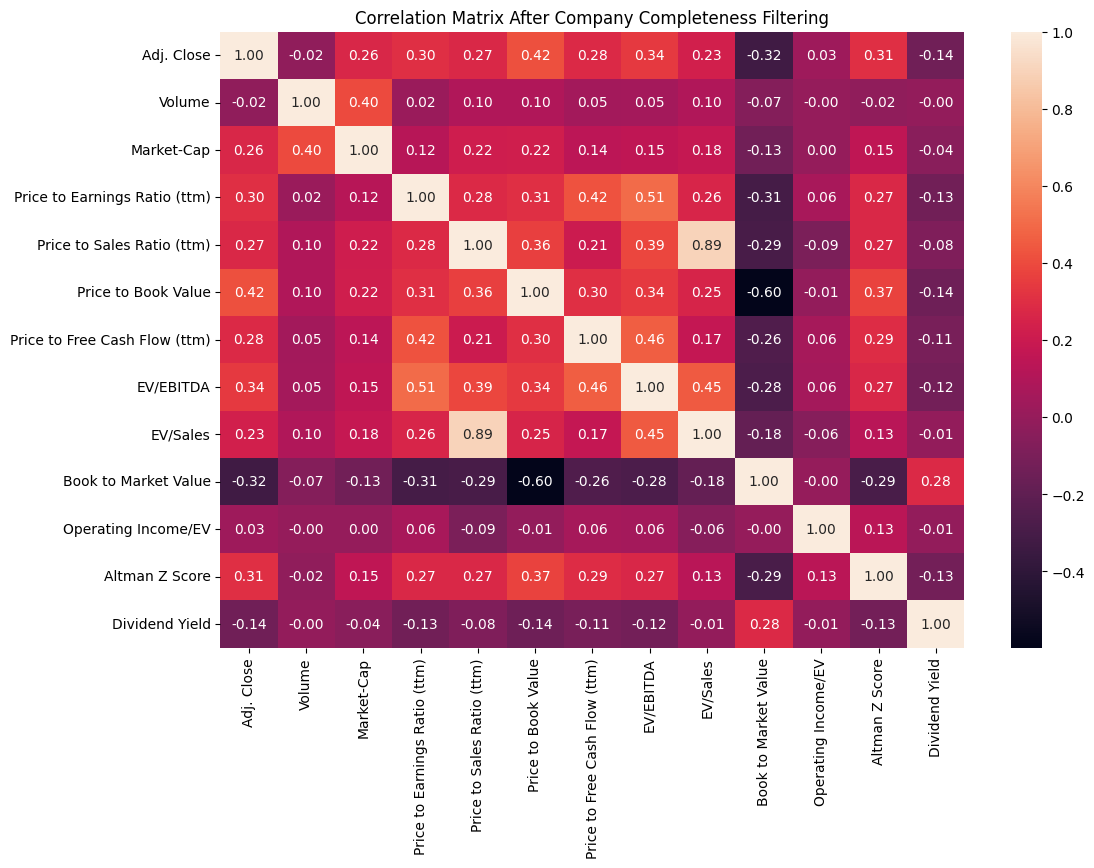

In [30]:
correlations = company_features_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

seaborn.heatmap(
    correlations,
    cbar=True,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix After Company Completeness Filtering")
plt.show()

In the baseline model we already explored applying feature selection, or including all features. The baseline showed a model containing all features achieving better results. So for this model we will continue with that approach. Especially since our current correlations don't show any reason to do otherwise.

# Feature engineering

Here we will create 3 target variable that we are gonna test and compare results.
1. The stakeholders stock price in 1 year
2. Price change absolute in 1 year
3. Price change percentage in 1 year

In [31]:
company_filtered_df.sort_values(
    ["Ticker", "Date"]
).head(20)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield,Month
0,A,2022-01-03,151.74,1606323.0,4.737004e+10,39.44331,7.55284,8.85626,31.21413,29.09115,7.67907,0.11291,0.02776,6.63193,0.00494,2022-01
1,A,2022-01-04,146.61,2233958.0,4.576864e+10,38.10988,7.29751,8.55687,30.15889,28.13108,7.42564,0.11687,0.02871,6.45119,0.00512,2022-01
2,A,2022-01-05,144.10,2370529.0,4.498459e+10,37.45702,7.17250,8.41028,29.64225,27.66102,7.30156,0.11890,0.02919,6.36269,0.00521,2022-01
3,A,2022-01-06,144.60,2298277.0,4.514200e+10,37.58810,7.19759,8.43971,29.74598,27.75540,7.32648,0.11849,0.02910,6.38046,0.00519,2022-01
4,A,2022-01-07,140.75,2058658.0,4.394020e+10,36.58740,7.00597,8.21502,28.95405,27.03489,7.13629,0.12173,0.02987,6.24482,0.00533,2022-01
5,A,2022-01-10,140.76,2548145.0,4.394322e+10,36.58992,7.00646,8.21559,28.95605,27.03670,7.13677,0.12172,0.02987,6.24516,0.00533,2022-01
6,A,2022-01-11,142.20,2028671.0,4.439125e+10,36.96298,7.07789,8.29935,29.25128,27.30531,7.20767,0.12049,0.02957,6.29573,0.00528,2022-01
7,A,2022-01-12,144.98,2250847.0,4.526007e+10,37.68640,7.21642,8.46178,29.82377,27.82618,7.34516,0.11818,0.02902,6.39379,0.00518,2022-01
8,A,2022-01-13,140.77,1741764.0,4.394625e+10,36.59244,7.00694,8.21615,28.95804,27.03852,7.13724,0.12171,0.02987,6.24550,0.00533,2022-01
9,A,2022-01-14,140.30,2225442.0,4.379792e+10,36.46893,6.98329,8.18842,28.86030,26.94959,7.11377,0.12212,0.02997,6.22876,0.00535,2022-01


Since our target variable needs to be adjusted based on date column. We should see what the date column looks like, it appears to be daily stock data. The dataset doesn't contain weekend data which creates an issue. Since our target variable is 1 year in the future. We can't just increment all data with 1 year or we will place data in weekends.

Columns we need
- Ticker: Unique identifier
- Date: Unique identifier
- Target variable, and the target variables we want to calculate will be derived from this

Before we can engineer the desired columns we need to check if the columns are usable

In [32]:
critical_cols = [
    "Ticker",
    "Date",
    "Adj. Close"
]

for col in critical_cols:

    print("\n", col)

    print(
        "Missing:",
        company_filtered_df[col].isna().sum()
    )

    print(
        "Missing %:",
        round(
            company_filtered_df[col].isna().mean() * 100,
            4
        )
    )


 Ticker
Missing: 0
Missing %: 0.0

 Date
Missing: 0
Missing %: 0.0

 Adj. Close
Missing: 91
Missing %: 0.0075


In [33]:
parsed_dates = pd.to_datetime(
    company_filtered_df["Date"],
    errors="coerce"
)

print(
    "Invalid Dates:",
    parsed_dates.isna().sum()
)

Invalid Dates: 0


In [34]:
(
    company_filtered_df["Ticker"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

np.int64(0)

In [35]:
duplicates = company_filtered_df.duplicated(
    subset=["Ticker", "Date"]
).sum()

print(
    "Duplicate Ticker-Date combinations:",
    duplicates
)

Duplicate Ticker-Date combinations: 0


In [36]:
print(
    company_filtered_df["Adj. Close"]
    .describe()
)

count    1.215663e+06
mean     7.885948e+01
std      1.120728e+02
min      1.000000e-01
25%      1.590000e+01
50%      3.838000e+01
75%      9.561000e+01
max      1.857000e+03
Name: Adj. Close, dtype: float64


In [37]:
print(
    "Zero prices:",
    (company_filtered_df["Adj. Close"] == 0).sum()
)

print(
    "Negative prices:",
    (company_filtered_df["Adj. Close"] < 0).sum()
)

Zero prices: 0
Negative prices: 0


Based on these checks we see that date column is fine but. Adjusted close and ticker columns contain missing values. Since the target variables will be derived from this we first have to solve these missing values or the columns won't be usable.

In [38]:
target_missing_df = company_filtered_df[
    company_filtered_df[critical_cols]
    .isna()
    .any(axis=1)
].copy()

print("Rows with target-engineering issues:")
print(len(target_missing_df))

Rows with target-engineering issues:
91


In [39]:
target_missing_df.sample(
    20,
    random_state=42
)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield,Month
3010984,MRMD,2025-06-17,NaN,326154.0,27246089.0,-1.65926,0.16859,0.36070,1.30183,6.79447,0.58490,2.77239,0.02503,0.14342,0.00570,2025-06
3010966,MRMD,2025-05-21,NaN,255850.0,31138387.0,-1.89630,0.19267,0.41223,1.48780,7.08029,0.60951,2.42583,0.02402,0.16084,0.00499,2025-05
3011004,MRMD,2025-07-17,NaN,348306.0,35030686.0,-2.13333,0.21676,0.46376,1.67378,7.36611,0.63411,2.15629,0.02309,0.17826,0.00443,2025-07
4798297,VRAY,2023-07-21,NaN,NaN,10862747.0,-0.09866,NaN,0.19714,-0.23235,-0.07129,0.06925,5.07254,NaN,-6.13627,NaN,2023-07
823682,CASA,2024-04-03,NaN,NaN,NaN,-0.04892,NaN,NaN,-0.07522,-1.91788,0.40733,-10.19056,-0.63476,-1.12590,0.00000,2024-04
3010970,MRMD,2025-05-28,NaN,792741.0,27246089.0,-1.65926,0.16859,0.36070,1.30183,6.79447,0.58490,2.77239,0.02503,0.14342,0.00570,2025-05
3010983,MRMD,2025-06-16,NaN,377294.0,27246089.0,-1.65926,0.16859,0.36070,1.30183,6.79447,0.58490,2.77239,0.02503,0.14342,0.00570,2025-06
3011096,MRMD,2025-11-25,NaN,793355.0,31605890.0,-1.75394,0.19632,0.44792,1.06462,6.76022,0.61172,2.23254,0.02680,0.12743,0.00433,2025-11
3010940,MRMD,2025-04-14,NaN,333242.0,34395658.0,-2.86297,0.21574,0.44004,2.06086,6.85903,0.63443,2.27252,0.03759,0.23670,0.00407,2025-04
3010988,MRMD,2025-06-24,NaN,214974.0,27246089.0,-1.65926,0.16859,0.36070,1.30183,6.79447,0.58490,2.77239,0.02503,0.14342,0.00570,2025-06


We can see by taking a sample of the missing values. That the missing values rows contain mostly missing values

In [40]:
target_missing_df.isna().mean(axis=1).describe()

count    91.000000
mean      0.103709
std       0.111110
min       0.062500
25%       0.062500
50%       0.062500
75%       0.062500
max       0.500000
dtype: float64

Above confirms our earlier idea. That the average row misses around 55% of data. Since we filtered the list

In [41]:
company_filtered_df["Target_Missing"] = (
    company_filtered_df[critical_cols]
    .isna()
    .any(axis=1)
)

company_filtered_df["Date"] = pd.to_datetime(
    company_filtered_df["Date"],
    errors="coerce"
)

In [42]:
missing_by_year = (
    company_filtered_df
    .groupby(company_filtered_df["Date"].dt.year)["Target_Missing"]
    .mean()
    .mul(100)
    .sort_index()
)

missing_by_year

Date
2022    0.000921
2023    0.002257
2024    0.000673
2025    0.027931
Name: Target_Missing, dtype: float64

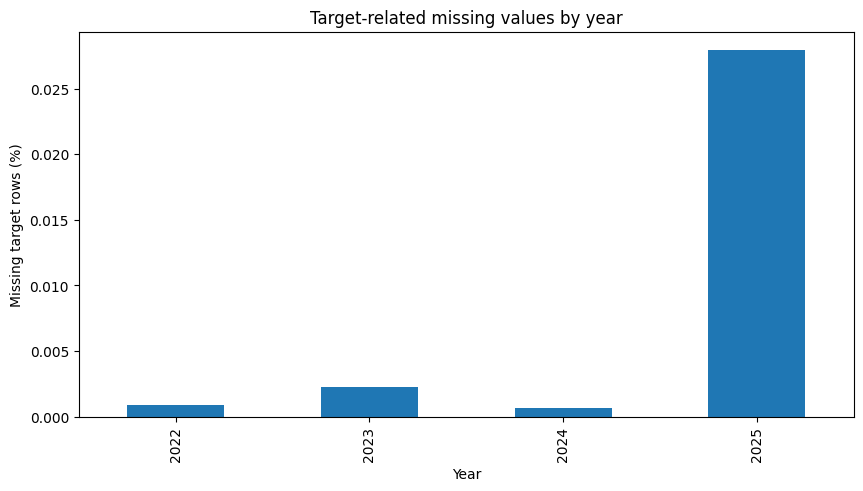

In [43]:
plt.figure(figsize=(10, 5))
missing_by_year.plot(kind="bar")
plt.title("Target-related missing values by year")
plt.xlabel("Year")
plt.ylabel("Missing target rows (%)")
plt.show()

In [44]:
missing_by_month = (
    company_filtered_df
    .groupby(company_filtered_df["Date"].dt.to_period("M"))["Target_Missing"]
    .mean()
    .mul(100)
    .sort_index()
)

missing_by_month

Date
2022-01    0.000000
2022-02    0.000000
2022-03    0.000000
2022-04    0.011489
2022-05    0.000000
2022-06    0.000000
2022-07    0.000000
2022-08    0.000000
2022-09    0.000000
2022-10    0.000000
2022-11    0.000000
2022-12    0.000000
2023-01    0.000000
2023-02    0.000000
2023-03    0.000000
2023-04    0.000000
2023-05    0.000000
2023-06    0.000000
2023-07    0.028172
2023-08    0.000000
2023-09    0.000000
2023-10    0.000000
2023-11    0.000000
2023-12    0.000000
2024-01    0.000000
2024-02    0.000000
2024-03    0.000000
2024-04    0.007651
2024-05    0.000000
2024-06    0.000000
2024-07    0.000000
2024-08    0.000000
2024-09    0.000000
2024-10    0.000000
2024-11    0.000000
2024-12    0.000000
2025-01    0.000000
2025-02    0.000000
2025-03    0.004166
2025-04    0.050195
2025-05    0.058622
2025-06    0.087974
2025-07    0.032180
2025-08    0.000000
2025-09    0.000000
2025-10    0.000000
2025-11    0.056444
2025-12    0.048958
Freq: M, Name: Target_Missing, dtyp

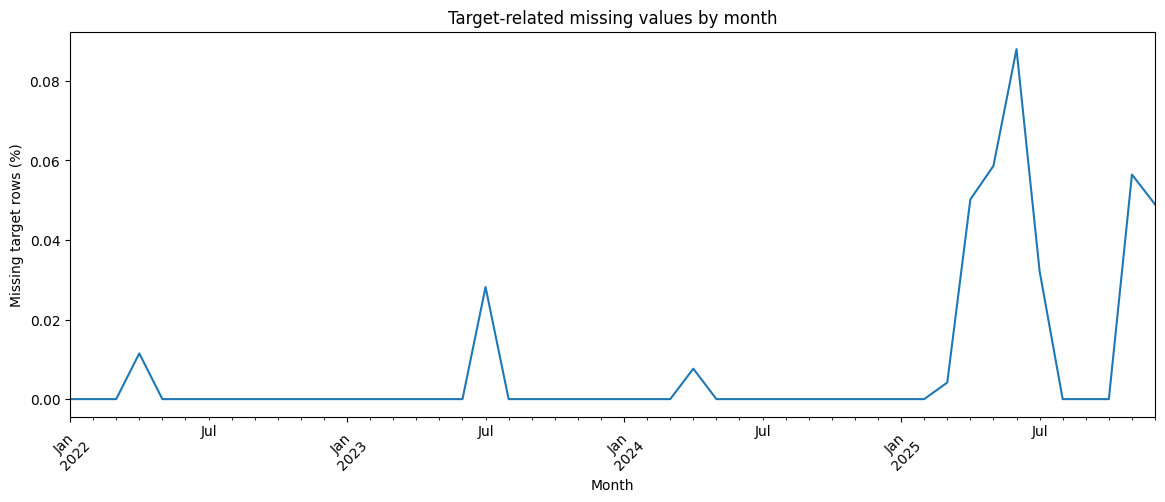

In [45]:
plt.figure(figsize=(14, 5))
missing_by_month.plot()
plt.title("Target-related missing values by month")
plt.xlabel("Month")
plt.ylabel("Missing target rows (%)")
plt.xticks(rotation=45)
plt.show()

In [46]:
missing_by_ticker = (
    company_filtered_df
    .groupby("Ticker")["Target_Missing"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

In [47]:
missing_count_by_ticker = (
    company_filtered_df[company_filtered_df["Target_Missing"]]
    ["Ticker"]
    .value_counts()
)

In [48]:
ticker_missing_summary = pd.DataFrame({
    "Missing %": missing_by_ticker,
    "Missing Count": missing_count_by_ticker,
    "Total Rows": company_filtered_df.groupby("Ticker").size()
})

ticker_missing_summary["Missing Count"] = (
    ticker_missing_summary["Missing Count"]
    .fillna(0)
)

ticker_missing_summary = ticker_missing_summary.sort_values(
    ["Missing %", "Missing Count"],
    ascending=False
)

ticker_missing_summary.head(30)

,Missing %,Missing Count,Total Rows
Ticker,,,
MRMD,7.876371,79.0,1003
VRAY,1.790281,7.0,391
CASA,0.353357,2.0,566
NUTX,0.299103,3.0,1003
A,0.000000,0.0,1003
AA,0.000000,0.0,1003
AAIC,0.000000,0.0,491
AAN,0.000000,0.0,692
AAOI,0.000000,0.0,1003


In [49]:
(
    company_filtered_df
    .groupby("Ticker")["Adj. Close"]
    .apply(lambda x: x.isna().mean() * 100)
    .describe()
)

count    1358.000000
mean        0.007599
std         0.219496
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.876371
Name: Adj. Close, dtype: float64

The missing Adjusted Close values were analysed at company level by calculating the percentage of missing Adjusted Close values per ticker. The results showed that at least 75% of companies had no missing Adjusted Close values. However, the maximum missing percentage was 100%, indicating that for some companies all Adjusted Close values were removed during percentile-based cleaning. This confirms that the missing values are concentrated in a smaller group of companies rather than being randomly distributed across the full dataset.

Confirming that with our percentile based cleaning we excluded higher stock price companies which no don't have data anymore as expected.

Since ticker missing percentage is so small and it is not a numeric column the influence of the missing values will be small enough to negate since their impact will be negligible.

# Creating target variables

In [50]:
target_ready_df = company_filtered_df.dropna(
    subset=[
        "Ticker",
        "Date",
        "Adj. Close"
    ]
).copy()

target_ready_df["Date"] = pd.to_datetime(
    target_ready_df["Date"],
    errors="coerce"
)

target_ready_df = target_ready_df.dropna(
    subset=["Date"]
).copy()

print("Rows ready for target engineering:", len(target_ready_df))
print("Companies:", target_ready_df["Ticker"].nunique())

Rows ready for target engineering: 1215663
Companies: 1358


In [51]:
target_ready_df = target_ready_df.sort_values(
    ["Ticker", "Date"]
).copy()

target_ready_df["Target Date"] = (
    target_ready_df["Date"] + pd.DateOffset(years=1)
)

In [52]:
def add_future_prices(group):
    ticker = group.name

    group = group.sort_values("Date").copy()

    future = (
        group[["Date", "Adj. Close"]]
        .rename(
            columns={
                "Date": "Future Date",
                "Adj. Close": "Future Adj Close"
            }
        )
        .sort_values("Future Date")
    )

    merged = pd.merge_asof(
        group.sort_values("Target Date"),
        future,
        left_on="Target Date",
        right_on="Future Date",
        direction="forward",
        tolerance=pd.Timedelta(days=7)
    )

    merged["Ticker"] = ticker

    return merged


target_ready_df = (
    target_ready_df
    .groupby("Ticker", group_keys=False)
    .apply(add_future_prices)
    .reset_index(drop=True)
)

In [53]:
target_ready_df["Price Change"] = (
    target_ready_df["Future Adj Close"]
    - target_ready_df["Adj. Close"]
)

target_ready_df["Price Change %"] = (
    target_ready_df["Price Change"]
    / target_ready_df["Adj. Close"]
) * 100

In [54]:
target_ready_df[
    [
        "Ticker",
        "Date",
        "Adj. Close",
        "Target Date",
        "Future Date",
        "Future Adj Close",
        "Price Change",
        "Price Change %"
    ]
].sample(20, random_state=42)

,Ticker,Date,Adj. Close,Target Date,Future Date,Future Adj Close,Price Change,Price Change %
789167,NUE,2025-01-13,120.50,2026-01-13,NaT,NaN,NaN,NaN
486934,HBT,2023-02-10,19.84,2024-02-10,2024-02-12,18.50,-1.34,-6.754032
184874,CHD,2023-08-01,93.29,2024-08-01,2024-08-01,97.93,4.64,4.973738
660174,LOPE,2024-02-15,133.34,2025-02-15,2025-02-18,185.52,52.18,39.133043
749483,MUSA,2022-12-29,276.57,2023-12-29,2023-12-29,352.70,76.13,27.526485
361225,ESOA,2025-12-16,8.64,2026-12-16,NaT,NaN,NaN,NaN
327400,EBAY,2023-08-16,40.87,2024-08-16,2024-08-16,54.01,13.14,32.150722
100004,AZZ,2025-10-24,98.51,2026-10-24,NaT,NaN,NaN,NaN
413391,FOX_old,2024-08-26,37.35,2025-08-26,2025-08-26,53.40,16.05,42.971888
974555,SIRI,2023-06-13,34.55,2024-06-13,2024-06-13,23.48,-11.07,-32.040521


Because the target variable represents the stock price approximately one year in the future, observations near the end of the dataset cannot have a known target value yet. These rows were not removed from the cleaned dataset, but they were excluded from the supervised training dataset because their true future outcome is unavailable. They can still be used later as prediction/inference data once the trained model is applied to recent observations.

In [55]:
target_cols = [
    "Future Adj Close",
    "Price Change",
    "Price Change %"
]

model_df = target_ready_df.dropna(
    subset=target_cols
).copy()

rows_before = len(target_ready_df)
rows_after = len(model_df)
rows_removed = rows_before - rows_after

print("Rows before target drop:", rows_before)
print("Rows after target drop:", rows_after)
print("Rows removed:", rows_removed)
print("Rows removed percentage:", rows_removed / rows_before * 100)

print(model_df["Date"].describe())

Rows before target drop: 1215663
Rows after target drop: 887819
Rows removed: 327844
Rows removed percentage: 26.96832921623838
count                        887819
mean     2023-06-19 23:41:23.772481
min             2022-01-03 00:00:00
25%             2022-09-16 00:00:00
50%             2023-06-13 00:00:00
75%             2024-03-19 00:00:00
max             2024-12-31 00:00:00
Name: Date, dtype: object


# Seperating target variable from dataset

In [68]:
feature_cols = [
    "Adj. Close",
    "Volume",
    "Market-Cap",
    "Price to Earnings Ratio (ttm)",
    "Price to Sales Ratio (ttm)",
    "Price to Book Value",
    "Price to Free Cash Flow (ttm)",
    "EV/EBITDA",
    "EV/Sales",
    "Book to Market Value",
    "Operating Income/EV",
    "Altman Z Score",
]

model_df_complete  = model_df.dropna(
    subset=feature_cols + target_cols
).copy()

print("Rows before removing remaining missing feature values:", len(model_df))
print("Rows after removing remaining missing feature values:", len(model_df_complete))
print("Rows removed:", len(model_df) - len(model_df_complete))
print("Rows removed %:", (len(model_df) - len(model_df_complete)) / len(model_df) * 100)

Rows before removing remaining missing feature values: 887819
Rows after removing remaining missing feature values: 671082
Rows removed: 216737
Rows removed %: 24.412295749471458


Dividend Yield was removed from the feature set because it still contained a high percentage of missing values after cleaning and company filtering. Keeping this feature would require heavy imputation or would remove a large amount of data. After removing Dividend Yield, the remaining missing values in the selected features were much lower. These remaining incomplete rows were removed before the train-validation split, so that the feature matrix and target variables remained aligned.

In [69]:
X = model_df_complete[feature_cols].copy()

y_future_price = model_df_complete["Future Adj Close"].copy()
y_price_change = model_df_complete["Price Change"].copy()
y_price_change_pct = model_df_complete["Price Change %"].copy()

In [70]:
print("X shape:", X.shape)
print("Future price target shape:", y_future_price.shape)
print("Price change target shape:", y_price_change.shape)
print("Price change % target shape:", y_price_change_pct.shape)

X shape: (671082, 12)
Future price target shape: (671082,)
Price change target shape: (671082,)
Price change % target shape: (671082,)


In [71]:
X.isna().mean().sort_values(ascending=False) * 100

Adj. Close                       0.0
Volume                           0.0
Market-Cap                       0.0
Price to Earnings Ratio (ttm)    0.0
Price to Sales Ratio (ttm)       0.0
Price to Book Value              0.0
Price to Free Cash Flow (ttm)    0.0
EV/EBITDA                        0.0
EV/Sales                         0.0
Book to Market Value             0.0
Operating Income/EV              0.0
Altman Z Score                   0.0
dtype: float64

# Split dataset training / validation

In [72]:
from sklearn.model_selection import train_test_split


target_cols = [
    "Future Adj Close",
    "Price Change",
    "Price Change %"
]

X = model_df_complete[feature_cols].copy()
y = model_df_complete[target_cols].copy()

X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
y_future_train = y_train["Future Adj Close"]
y_future_validation = y_validation["Future Adj Close"]

y_change_train = y_train["Price Change"]
y_change_validation = y_validation["Price Change"]

y_change_pct_train = y_train["Price Change %"]
y_change_pct_validation = y_validation["Price Change %"]

In [74]:
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)

X_train: (536865, 12)
X_validation: (134217, 12)
y_train: (536865, 3)
y_validation: (134217, 3)


In [75]:
print("Missing values in X_train:")
print(
    X_train
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nMissing values in X_validation:")
print(
    X_validation
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

Missing values in X_train:
Adj. Close                       0.0
Volume                           0.0
Market-Cap                       0.0
Price to Earnings Ratio (ttm)    0.0
Price to Sales Ratio (ttm)       0.0
Price to Book Value              0.0
Price to Free Cash Flow (ttm)    0.0
EV/EBITDA                        0.0
EV/Sales                         0.0
Book to Market Value             0.0
Operating Income/EV              0.0
Altman Z Score                   0.0
dtype: float64

Missing values in X_validation:
Adj. Close                       0.0
Volume                           0.0
Market-Cap                       0.0
Price to Earnings Ratio (ttm)    0.0
Price to Sales Ratio (ttm)       0.0
Price to Book Value              0.0
Price to Free Cash Flow (ttm)    0.0
EV/EBITDA                        0.0
EV/Sales                         0.0
Book to Market Value             0.0
Operating Income/EV              0.0
Altman Z Score                   0.0
dtype: float64


# Model trainen

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

training_targets = {
    "Future Adj Close": {
        "y_train": y_future_train,
        "y_validation": y_future_validation
    },
    "Price Change": {
        "y_train": y_change_train,
        "y_validation": y_change_validation
    },
    "Price Change %": {
        "y_train": y_change_pct_train,
        "y_validation": y_change_pct_validation
    }
}

models = {}
results = []

for target_name, target_data in training_targets.items():

    model = LinearRegression()

    model.fit(
        X_train,
        target_data["y_train"]
    )

    y_pred = model.predict(
        X_validation
    )

    mae = mean_absolute_error(
        target_data["y_validation"],
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            target_data["y_validation"],
            y_pred
        )
    )

    r2 = r2_score(
        target_data["y_validation"],
        y_pred
    )

    models[target_name] = model

    results.append({
        "Target": target_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Target,MAE,RMSE,R²
0,Future Adj Close,19.312589,38.611335,0.892099
1,Price Change,19.315253,38.609934,0.025936
2,Price Change %,30.268415,45.254882,0.001365


The results show that the Linear Regression model performs best when predicting Future Adjusted Close directly, with an R² score of 0.892. This indicates that the model can explain a large part of the variation in future stock prices. However, the performance is much lower for absolute price change and percentage price change, with R² scores of 0.026 and 0.001 respectively. This suggests that predicting the direction and magnitude of price movements is considerably more difficult than predicting the future price level itself. A likely explanation is that Future Adjusted Close is strongly related to the current Adjusted Close, while price changes contain more market noise and are less directly explained by the selected financial ratios.

In [ ]:
feature_cols_no_price = [
    col for col in feature_cols
    if col != "Adj. Close"
]

X_no_price = model_df_complete[feature_cols_no_price].copy()
y = model_df_complete[target_cols].copy()

X_train_np, X_validation_np, y_train_np, y_validation_np = train_test_split(
    X_no_price,
    y,
    test_size=0.2,
    random_state=42
)

model_no_price = LinearRegression()

model_no_price.fit(
    X_train_np,
    y_train_np["Future Adj Close"]
)

y_pred_no_price = model_no_price.predict(X_validation_np)

print("R² without current Adj. Close:")
print(
    r2_score(
        y_validation_np["Future Adj Close"],
        y_pred_no_price
    )
)

R² without current Adj. Close:
0.16983331252654799


In [ ]:
naive_pred = X_validation["Adj. Close"]

print("Naive baseline R²:")
print(
    r2_score(
        y_future_validation,
        naive_pred
    )
)

print("Naive baseline MAE:")
print(
    mean_absolute_error(
        y_future_validation,
        naive_pred
    )
)

print("Naive baseline RMSE:")
print(
    np.sqrt(
        mean_squared_error(
            y_future_validation,
            naive_pred
        )
    )
)

Naive baseline R²:
0.8857260542365037
Naive baseline MAE:
19.460853915673873
Naive baseline RMSE:
39.735274460867586


To verify whether the high R² score for Future Adjusted Close represented strong predictive performance, two additional checks were performed. First, a naive baseline was created where the future stock price was assumed to be equal to the current Adjusted Close. This baseline achieved an R² of 0.886, which is very close to the Linear Regression score of 0.892. Second, the model was trained again without the current Adjusted Close feature, which reduced the R² to 0.170. These results show that the high performance is mainly explained by the current stock price rather than by the financial ratios. Therefore, predicting the future price level directly is much easier than predicting price movement, but it provides limited additional value over a simple price-persistence baseline.

Future Adj Close lijkt goed, maar is grotendeels baseline-effect.
Price Change en Price Change % zijn moeilijker, maar inhoudelijk interessanter.

In [77]:
predictions = {}

for target_name, model in models.items():
    predictions[target_name] = model.predict(X_validation)

In [85]:
plot_limits = {
    "Future Adj Close": (
        model_df_complete["Future Adj Close"].quantile(0.001),
        model_df_complete["Future Adj Close"].quantile(0.999)
    ),
    "Price Change": (
        model_df_complete["Price Change"].quantile(0.001),
        model_df_complete["Price Change"].quantile(0.999)
    ),
    "Price Change %": (
        model_df_complete["Price Change %"].quantile(0.001),
        model_df_complete["Price Change %"].quantile(0.999)
    )
}

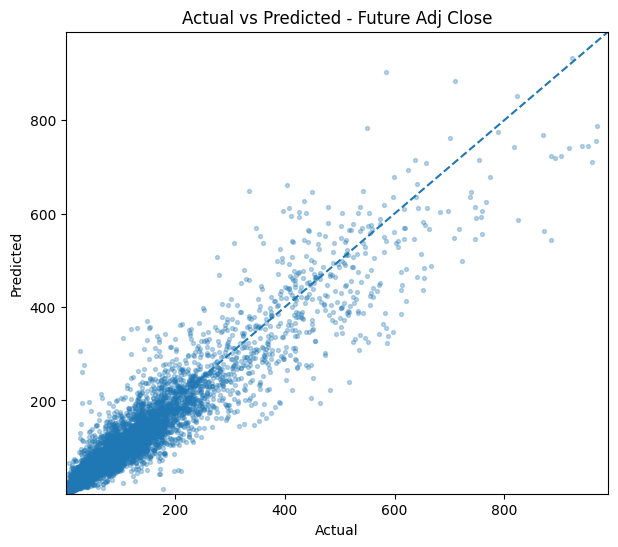

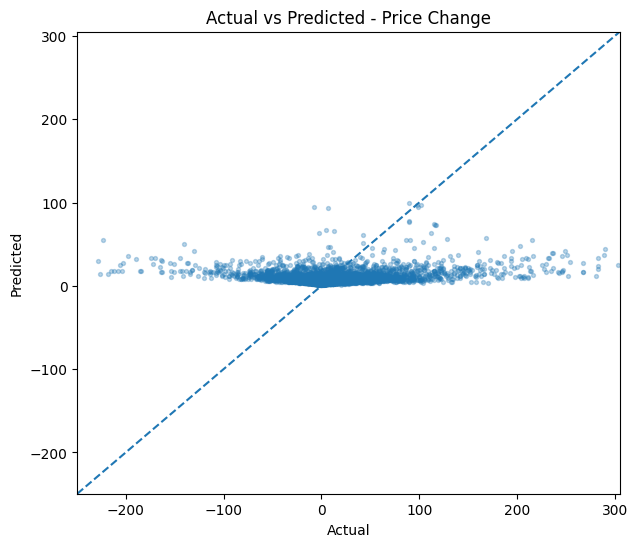

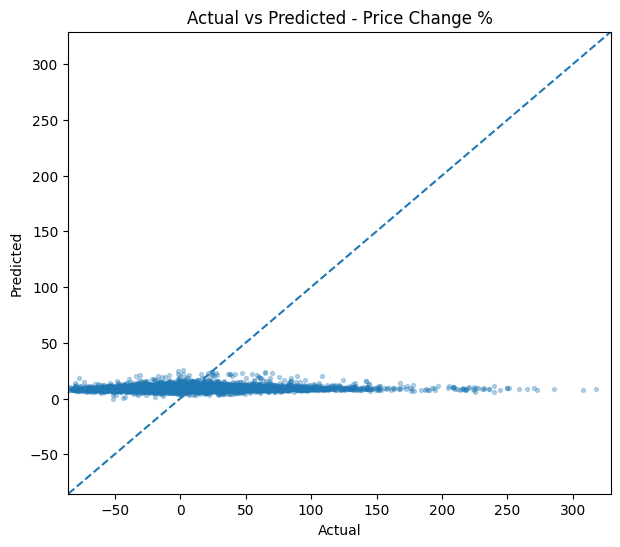

In [86]:
import matplotlib.pyplot as plt
validation_targets = {
    "Future Adj Close": y_future_validation,
    "Price Change": y_change_validation,
    "Price Change %": y_change_pct_validation
}

for target_name, y_true in validation_targets.items():

    y_pred = predictions[target_name]

    plot_df = pd.DataFrame({
        "Actual": y_true,
        "Predicted": y_pred
    }).sample(
        min(10000, len(y_true)),
        random_state=42
    )

    lower, upper = plot_limits[target_name]

    plot_df = plot_df[
        (plot_df["Actual"] >= lower) &
        (plot_df["Actual"] <= upper) &
        (plot_df["Predicted"] >= lower) &
        (plot_df["Predicted"] <= upper)
    ]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        plot_df["Actual"],
        plot_df["Predicted"],
        alpha=0.3,
        s=8
    )

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--"
    )

    plt.xlim(lower, upper)
    plt.ylim(lower, upper)

    plt.title(f"Actual vs Predicted - {target_name}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

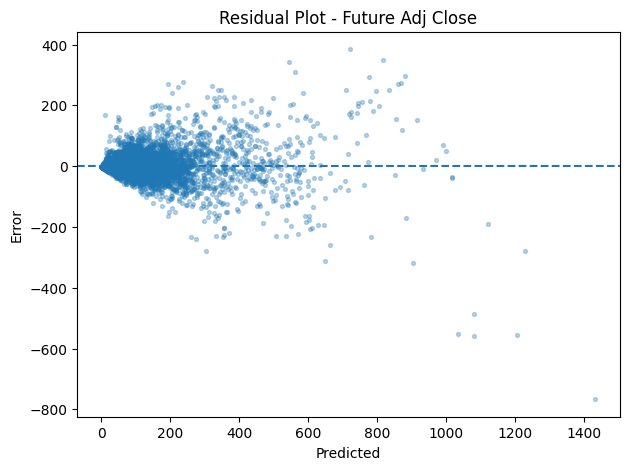

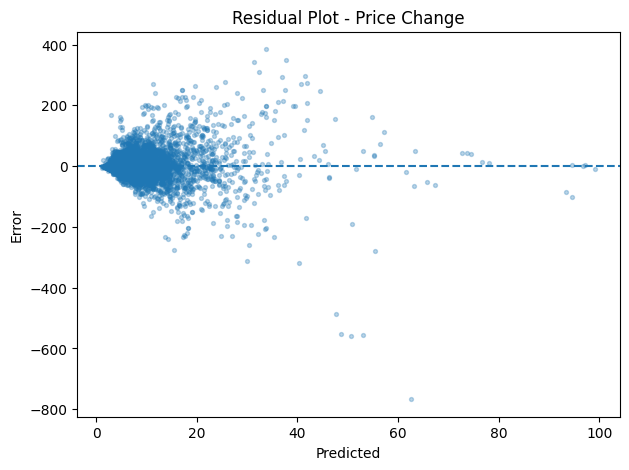

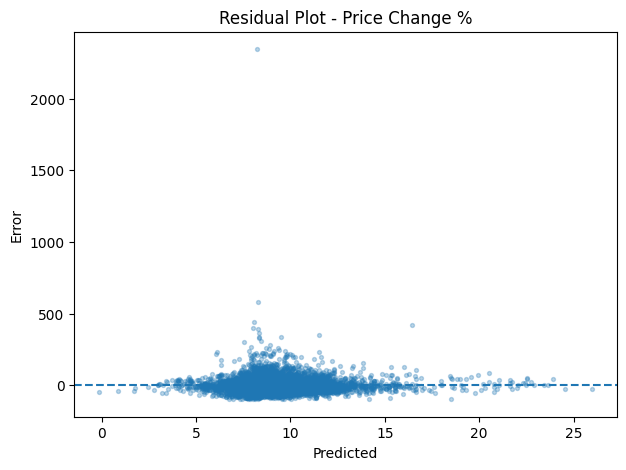

In [87]:
validation_targets = {
    "Future Adj Close": y_future_validation,
    "Price Change": y_change_validation,
    "Price Change %": y_change_pct_validation
}

for target_name, y_true in validation_targets.items():

    y_pred = predictions[target_name]

    error_df = pd.DataFrame({
        "Actual": y_true,
        "Predicted": y_pred
    })

    error_df["Error"] = (
        error_df["Actual"]
        - error_df["Predicted"]
    )

    error_df = error_df.sample(
        min(10000, len(error_df)),
        random_state=42
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        error_df["Predicted"],
        error_df["Error"],
        alpha=0.3,
        s=8
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.title(f"Residual Plot - {target_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Error")
    plt.show()

Error plots were created to inspect how the model predictions differ from the actual target values. Residual plots show whether the prediction errors are randomly distributed or whether certain predicted value ranges contain larger errors. Error distribution plots show the spread and skewness of the errors. This helps identify whether the model systematically overpredicts or underpredicts certain targets.

# Conclusion

This notebook focused on preparing the financial dataset for modelling and evaluating different target variables for stock prediction. The preprocessing started with selecting features that were relevant to the stakeholder and the value investing domain. Placeholder values and extreme outliers were investigated and converted to missing values where necessary. Missing values were then analysed over time and per company to understand whether they were random or structurally related to specific features, periods, or companies.

The analysis showed that some missing values were created by the percentile-based cleaning process. This was especially visible for Adjusted Close, where companies with structurally high stock prices were affected by the selected percentile thresholds. Since Adjusted Close is required for target engineering, rows without a valid Ticker, Date, or Adjusted Close value were removed before creating the target variables. Dividend Yield was also removed from the final feature set because it contained a high amount of missing data compared to the other selected features. After this, the remaining incomplete rows were dropped to create a complete modelling dataset.

Three target variables were created and compared: Future Adjusted Close, absolute Price Change, and percentage Price Change. The Linear Regression results showed that Future Adjusted Close achieved the highest R² score. However, further validation showed that this result was largely explained by the current Adjusted Close feature. A naive baseline that predicted the future price as equal to the current price performed almost as well as the Linear Regression model. When the current Adjusted Close feature was removed, the model performance dropped strongly. This indicates that the high score for Future Adjusted Close mainly reflects price persistence rather than strong predictive value from the financial ratios.

The Price Change and Price Change % targets performed much worse, suggesting that predicting actual stock movement is considerably more difficult than predicting future price level. However, these targets may be more meaningful from a financial and stakeholder perspective, because they focus on expected return rather than simply predicting the future price scale.

A relevant next step would be to further investigate the role of Adjusted Close and price-derived features. Many selected valuation ratios, such as P/E, P/S, P/B, P/FCF, and Market-Cap, are directly or indirectly based on stock price. This makes it important to test whether the model is learning meaningful financial relationships or mostly learning current market price information. Future experiments could compare models with and without Adjusted Close, and possibly also compare models using only fundamental or valuation ratios. This would provide a clearer understanding of whether the financial indicators themselves contain predictive value for future stock performance.